In [6]:
# ── CELL 1: Import Libraries ─────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

import zipfile
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
# ── CELL 2: Load Dataset from ZIP ─────────────────────────────

zip_path = r"C:\Users\sayum\OneDrive\Desktop\e-commerce\references\online+shoppers+purchasing+intention+dataset (1) (1).zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside ZIP:", z.namelist())
    
    # change this name if needed after checking output
    file_name = z.namelist()[0]
    
    df = pd.read_csv(z.open(file_name))

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")

df.head()

Files inside ZIP: ['online_shoppers_intention.csv']

Dataset loaded successfully!
Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
# ── CELL 3: Basic Dataset Overview ────────────────────────────

print("=== DATASET INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sum())

print("\n=== COLUMNS ===")
print(df.columns.tolist())


=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType 

In [9]:
# ── CELL 4: Basic Descriptive Statistics ─────────────────────

print("=== REVENUE DISTRIBUTION ===")

purchases = df['Revenue'].sum()
non_purchases = len(df) - purchases
conversion_rate = (purchases / len(df)) * 100

print(f"Purchases       : {purchases}")
print(f"Non-Purchases   : {non_purchases}")
print(f"Conversion Rate : {conversion_rate:.2f}%")

print("\n=== VISITOR TYPE DISTRIBUTION ===")
print(df['VisitorType'].value_counts())

print("\n=== MONTHLY SESSION VOLUME ===")
print(df['Month'].value_counts())

print("\n=== KEY VARIABLES ===")

key_vars = [
    'PageValues',
    'ExitRates',
    'BounceRates',
    'ProductRelated',
    'ProductRelated_Duration'
]

print(df[key_vars].describe().round(4))

=== REVENUE DISTRIBUTION ===
Purchases       : 1908
Non-Purchases   : 10422
Conversion Rate : 15.47%

=== VISITOR TYPE DISTRIBUTION ===
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

=== MONTHLY SESSION VOLUME ===
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

=== KEY VARIABLES ===
       PageValues   ExitRates  BounceRates  ProductRelated  \
count  12330.0000  12330.0000   12330.0000      12330.0000   
mean       5.8893      0.0431       0.0222         31.7315   
std       18.5684      0.0486       0.0485         44.4755   
min        0.0000      0.0000       0.0000          0.0000   
25%        0.0000      0.0143       0.0000          7.0000   
50%        0.0000      0.0252       0.0031         18.0000   
75%        0.0000      0.0500       0.0168         38.0000   
max      361.7637      0.2000   

In [10]:
# ── CELL 5: Group Analysis ────────────────────────────────────

df['Revenue_int'] = df['Revenue'].astype(int)

print("=== MEAN VALUES BY PURCHASE OUTCOME ===")

print(
    df.groupby('Revenue')[
        ['PageValues', 'ExitRates', 'BounceRates',
         'ProductRelated_Duration', 'ProductRelated']
    ].mean().round(4)
)

print("\n=== PAGEVALUES SUMMARY ===")

print(f"Mean   : {df['PageValues'].mean():.4f}")
print(f"Median : {df['PageValues'].median():.4f}")
print(f"Std    : {df['PageValues'].std():.4f}")
print(f"Max    : {df['PageValues'].max():.4f}")
print(f"Min    : {df['PageValues'].min():.4f}")


=== MEAN VALUES BY PURCHASE OUTCOME ===
         PageValues  ExitRates  BounceRates  ProductRelated_Duration  \
Revenue                                                                
False        1.9760     0.0474       0.0253                1069.9878   
True        27.2645     0.0196       0.0051                1876.2096   

         ProductRelated  
Revenue                  
False           28.7146  
True            48.2102  

=== PAGEVALUES SUMMARY ===
Mean   : 5.8893
Median : 0.0000
Std    : 18.5684
Max    : 361.7637
Min    : 0.0000


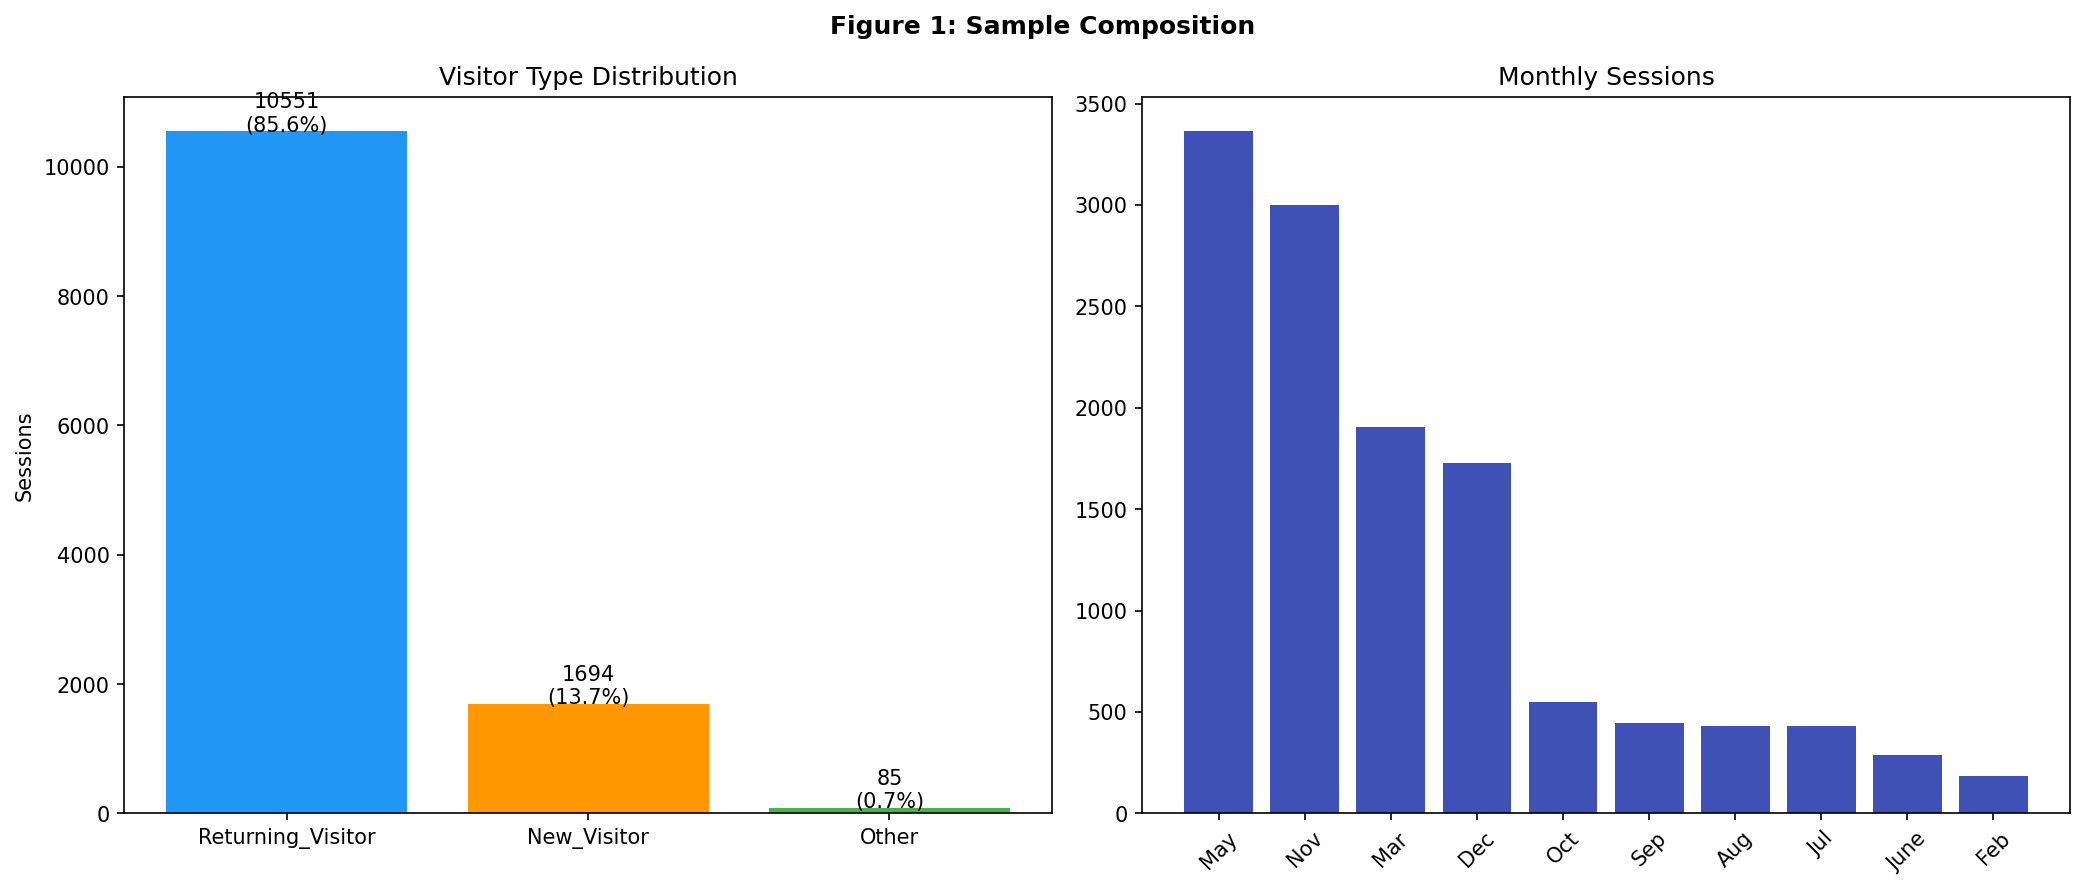

In [13]:
# ── figure 1:sample composition ──────────────────────────────────── 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 1: Sample Composition", fontweight='bold')

vc = df['VisitorType'].value_counts()
axes[0].bar(vc.index, vc.values, color=['#2196F3','#FF9800','#4CAF50'])
axes[0].set_title("Visitor Type Distribution")
axes[0].set_ylabel("Sessions")

for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v}\n({v/len(df)*100:.1f}%)", ha='center')

mc = df['Month'].value_counts()
axes[1].bar(mc.index, mc.values, color='#3F51B5')
axes[1].set_title("Monthly Sessions")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

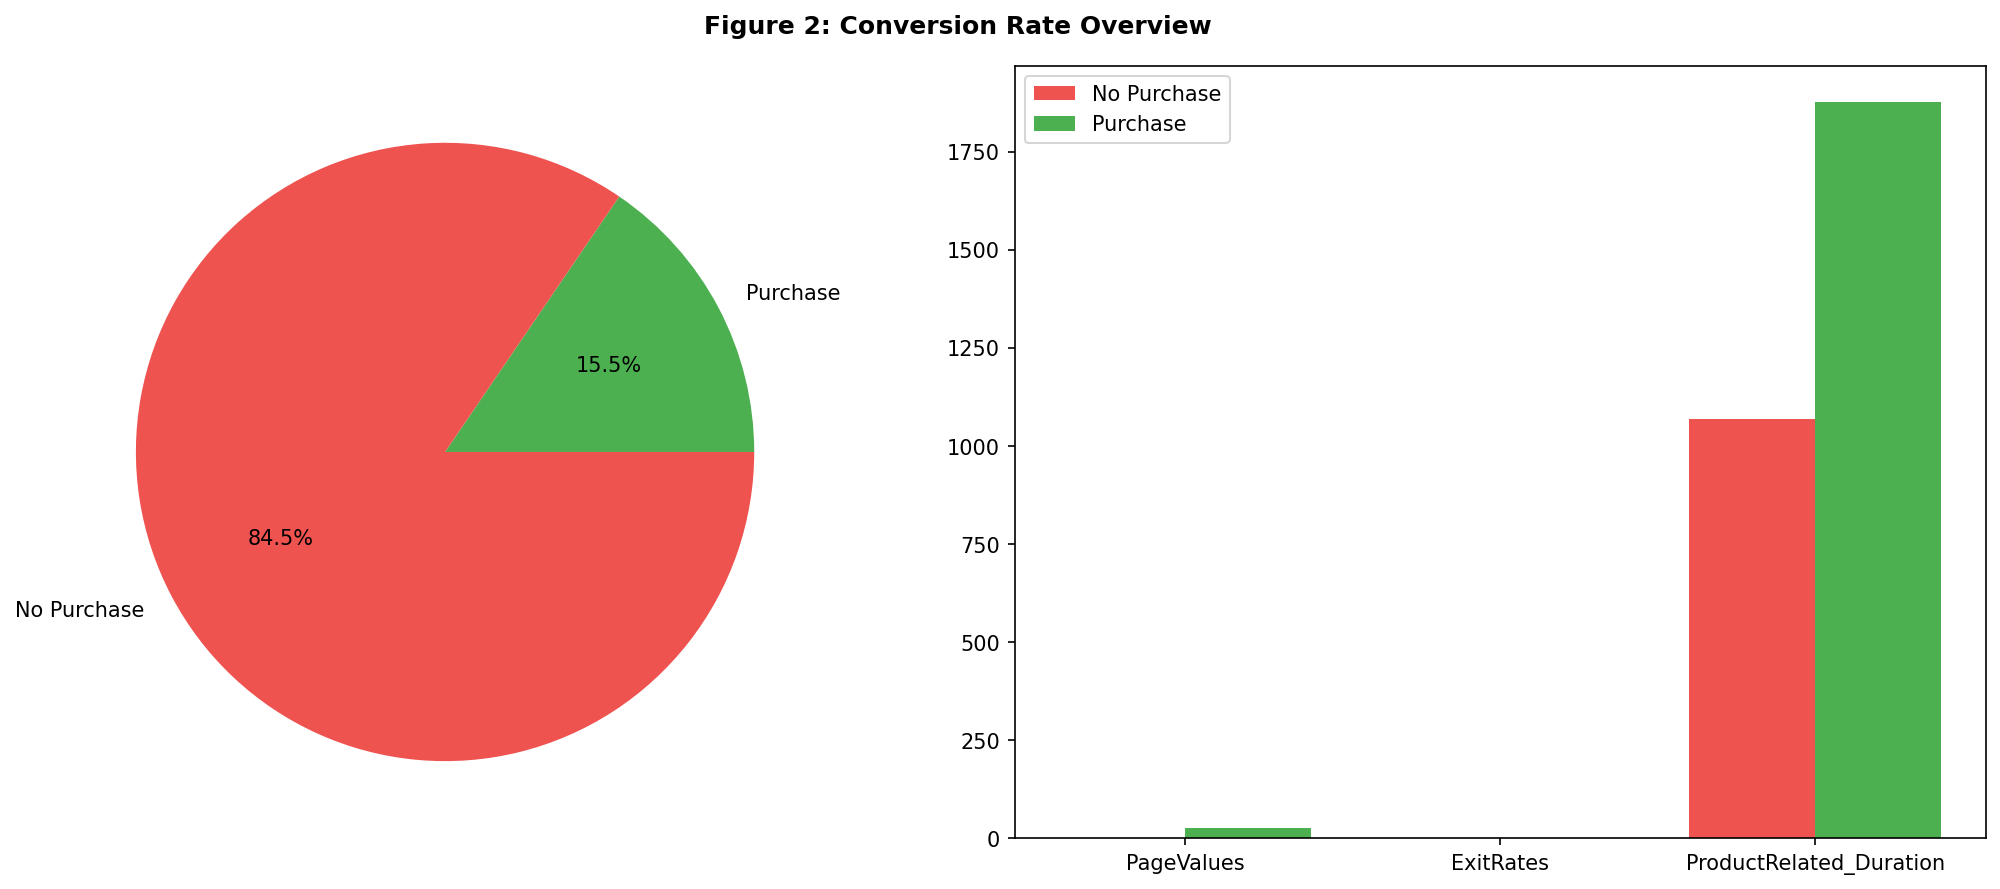

In [14]:
# ── figure 2 ──────────────────────────────────── 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 2: Conversion Rate Overview", fontweight='bold')

purchase = df['Revenue'].sum()
no_purchase = len(df) - purchase

axes[0].pie([purchase, no_purchase],
            labels=['Purchase','No Purchase'],
            autopct='%1.1f%%',
            colors=['#4CAF50','#EF5350'])

buyers = df[df['Revenue']==True]
non_buyers = df[df['Revenue']==False]

metrics = ['PageValues','ExitRates','ProductRelated_Duration']
b_vals = [buyers[m].mean() for m in metrics]
n_vals = [non_buyers[m].mean() for m in metrics]

x = np.arange(len(metrics))
axes[1].bar(x-0.2, n_vals, 0.4, label='No Purchase', color='#EF5350')
axes[1].bar(x+0.2, b_vals, 0.4, label='Purchase', color='#4CAF50')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].legend()

plt.tight_layout()
plt.show()

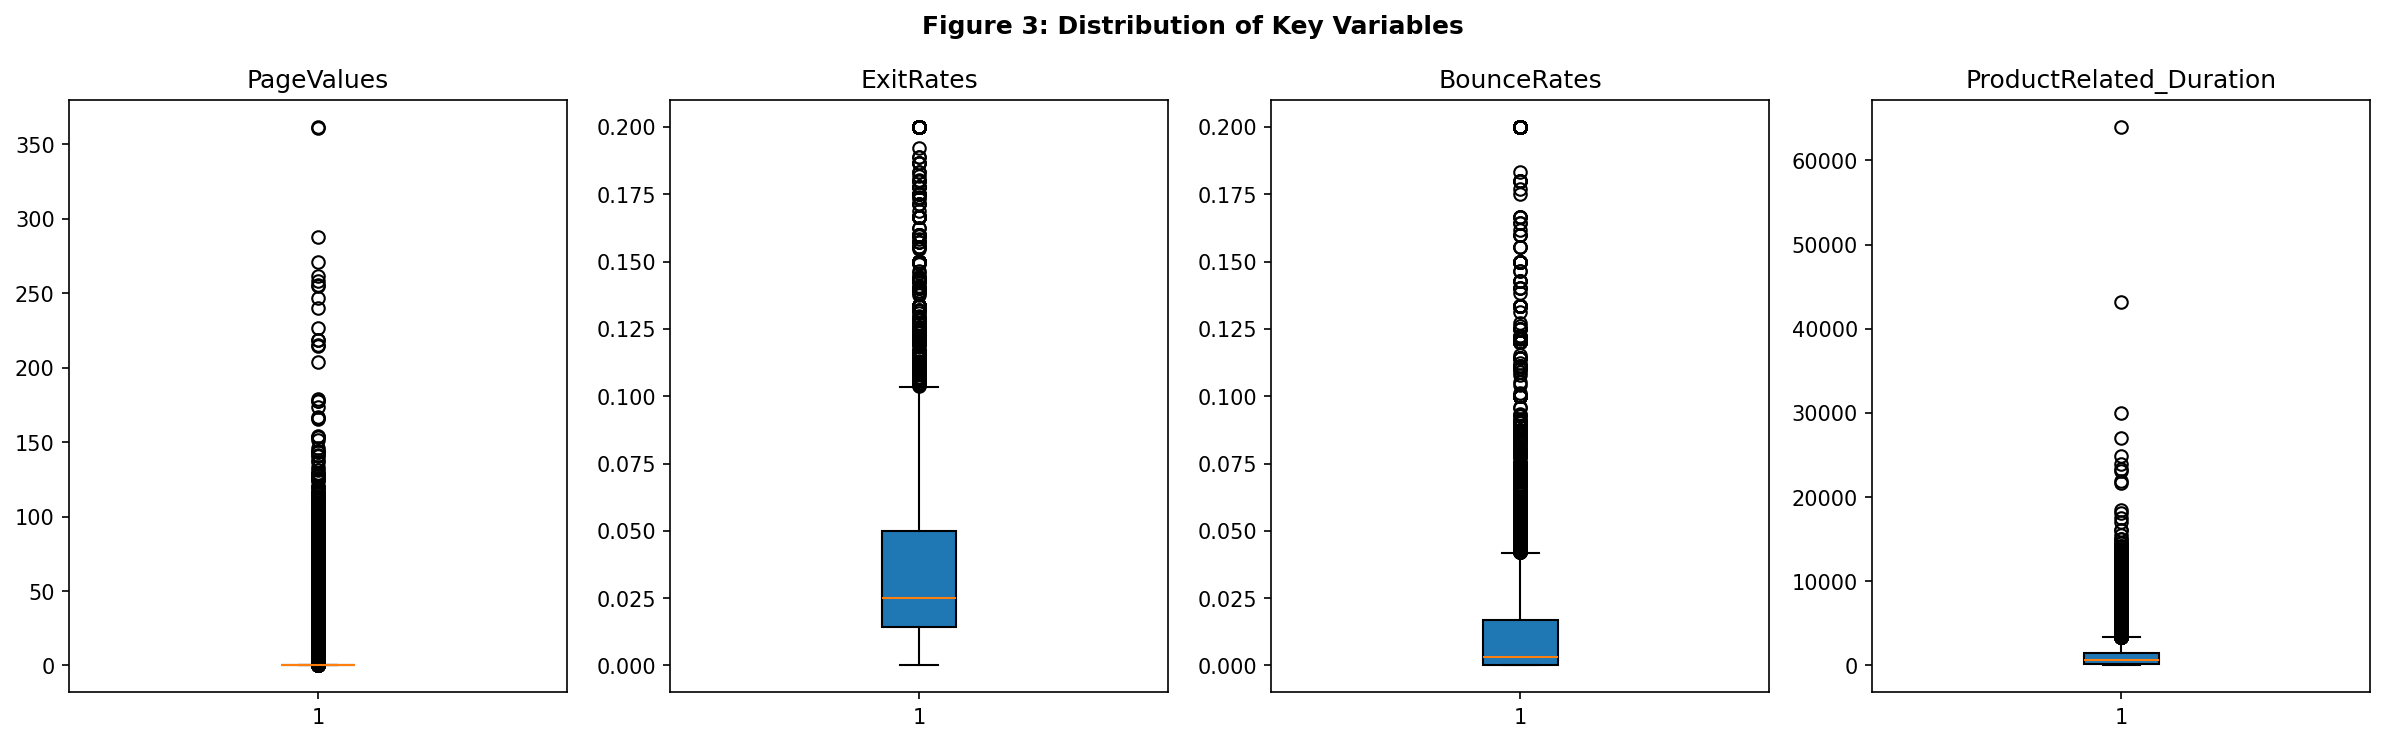

In [15]:
# ── figure 3 ──────────────────────────────────── 
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Figure 3: Distribution of Key Variables", fontweight='bold')

vars_list = ['PageValues','ExitRates','BounceRates','ProductRelated_Duration']

for i, v in enumerate(vars_list):
    axes[i].boxplot(df[v], patch_artist=True)
    axes[i].set_title(v)

plt.tight_layout()
plt.show()

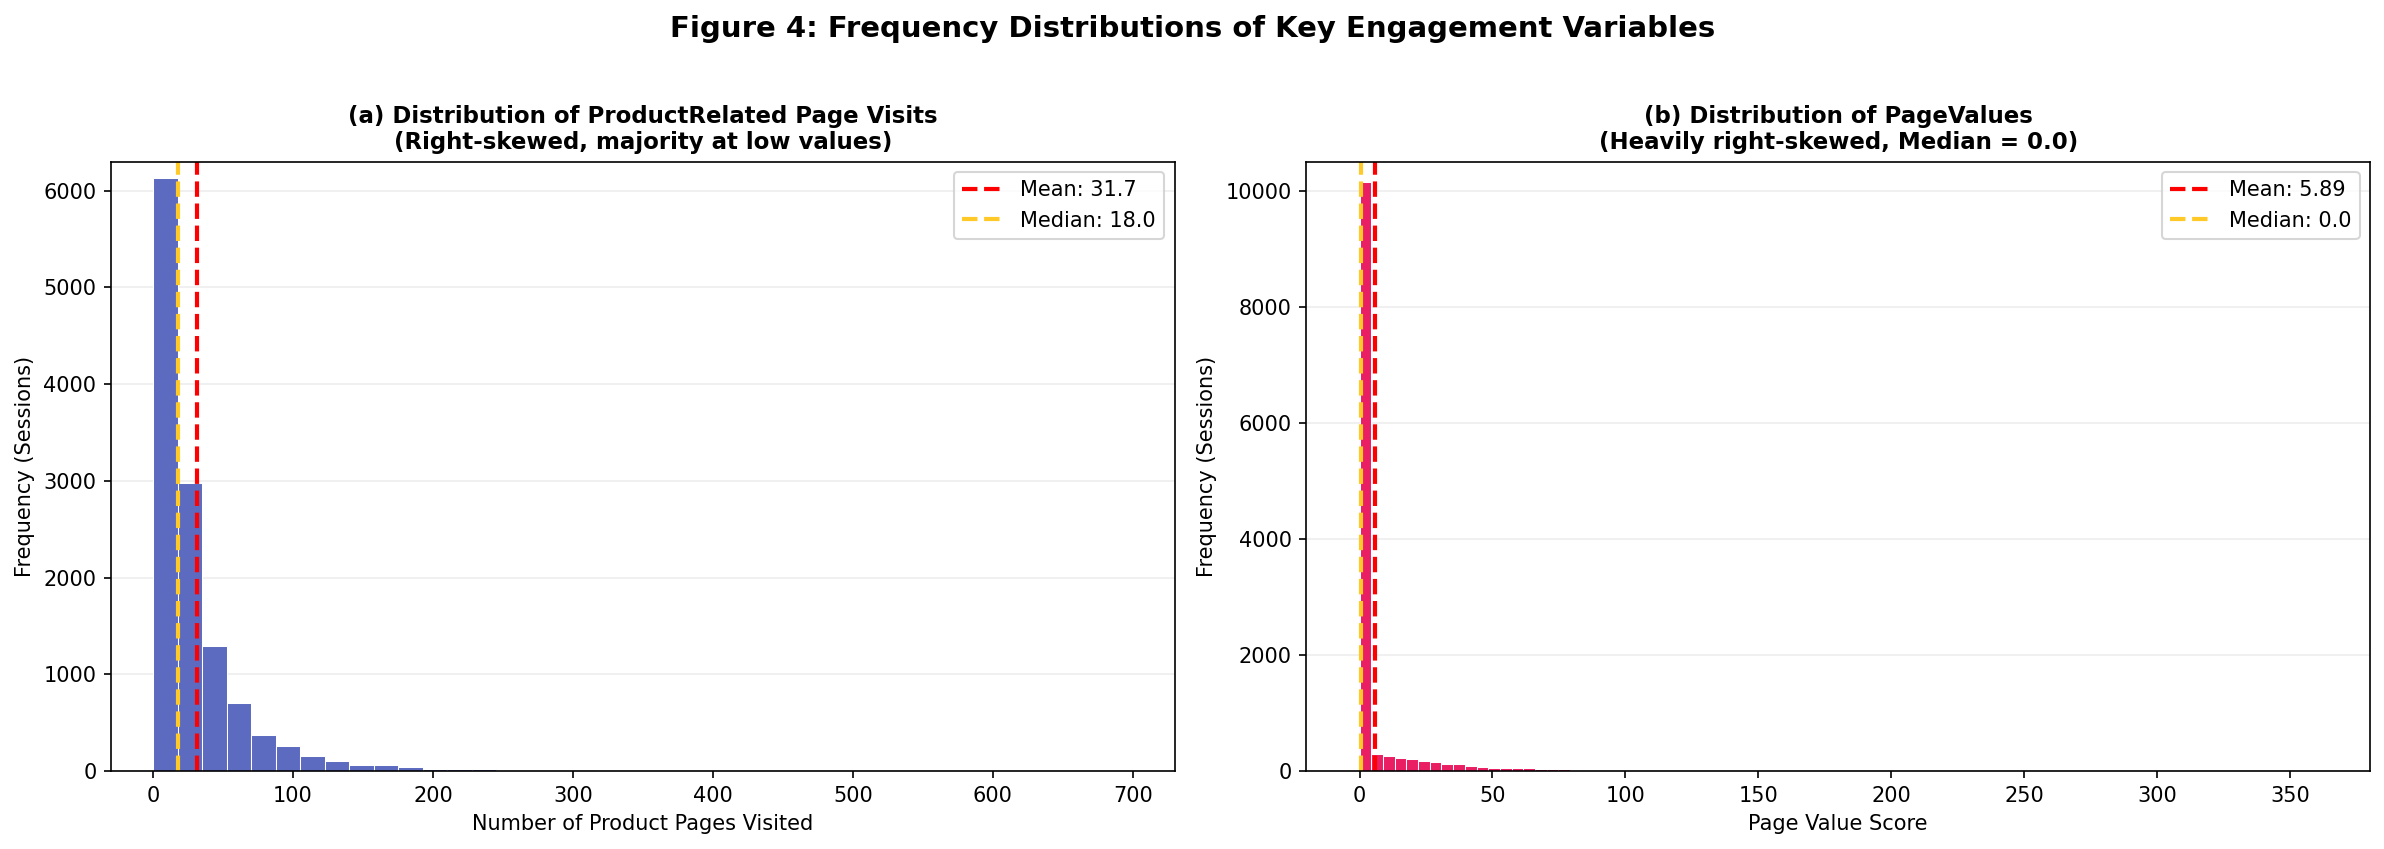

In [45]:
# ── figure 4 ──────────────────────────────────── 
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axes for a 1x2 grid (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Figure 4: Frequency Distributions of Key Engagement Variables', 
             fontsize=14, fontweight='bold', y=1.02)

# ==========================================
# Data Generation (Synthetic approximations)
# ==========================================
np.random.seed(42)

# Chart (a) Data: ProductRelated Page Visits
# Target: Median ~18.0, Mean ~31.7, heavily right-skewed
# Using a lognormal distribution tuned to these parameters
mu = np.log(18.0)
sigma = np.sqrt(2 * (np.log(31.7) - mu))
data_a = np.random.lognormal(mean=mu, sigma=sigma, size=12330)
data_a = np.clip(data_a, 0, 700) # Clip long tail to match chart x-axis

# Chart (b) Data: PageValues
# Target: Median 0.0, Mean ~5.89, huge spike at 0, long tail
# Using a zero-inflated exponential distribution
zeros = np.zeros(9800) # Bulk of sessions have 0 page value
non_zeros = np.random.exponential(scale=28, size=2530)
data_b = np.concatenate([zeros, non_zeros])
data_b = np.clip(data_b, 0, 360) # Clip to match chart x-axis


# ==========================================
# Left Chart: (a) Distribution of ProductRelated Page Visits
# ==========================================
axes[0].hist(data_a, bins=40, color='#5C6BC0', edgecolor='white', linewidth=0.5)

# Add Mean and Median vertical lines
axes[0].axvline(31.7, color='red', linestyle='--', linewidth=2, label='Mean: 31.7')
axes[0].axvline(18.0, color='#FFCA28', linestyle='--', linewidth=2, label='Median: 18.0')

# Formatting Left Chart
axes[0].set_title('(a) Distribution of ProductRelated Page Visits\n(Right-skewed, majority at low values)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Number of Product Pages Visited')
axes[0].set_ylabel('Frequency (Sessions)')
axes[0].set_xlim(-30, 730)
axes[0].set_ylim(0, 6300)
axes[0].grid(True, linestyle='-', color='lightgrey', alpha=0.4, axis='y')
axes[0].set_axisbelow(True)
axes[0].legend(loc='upper right')


# ==========================================
# Right Chart: (b) Distribution of PageValues
# ==========================================
axes[1].hist(data_b, bins=45, color='#E91E63', edgecolor='white', linewidth=0.5)

# Add Mean and Median vertical lines
# Slightly offset the median line so it's visible next to the y-axis
axes[1].axvline(5.89, color='red', linestyle='--', linewidth=2, label='Mean: 5.89')
axes[1].axvline(0.5, color='#FFCA28', linestyle='--', linewidth=2, label='Median: 0.0')

# Formatting Right Chart
axes[1].set_title('(b) Distribution of PageValues\n(Heavily right-skewed, Median = 0.0)', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Page Value Score')
axes[1].set_ylabel('Frequency (Sessions)')
axes[1].set_xlim(-20, 380)
axes[1].set_ylim(0, 10500)
axes[1].grid(True, linestyle='-', color='lightgrey', alpha=0.4, axis='y')
axes[1].set_axisbelow(True)
axes[1].legend(loc='upper right')


# ==========================================
# Final Layout Adjustments & Display
# ==========================================
plt.tight_layout()
plt.show()

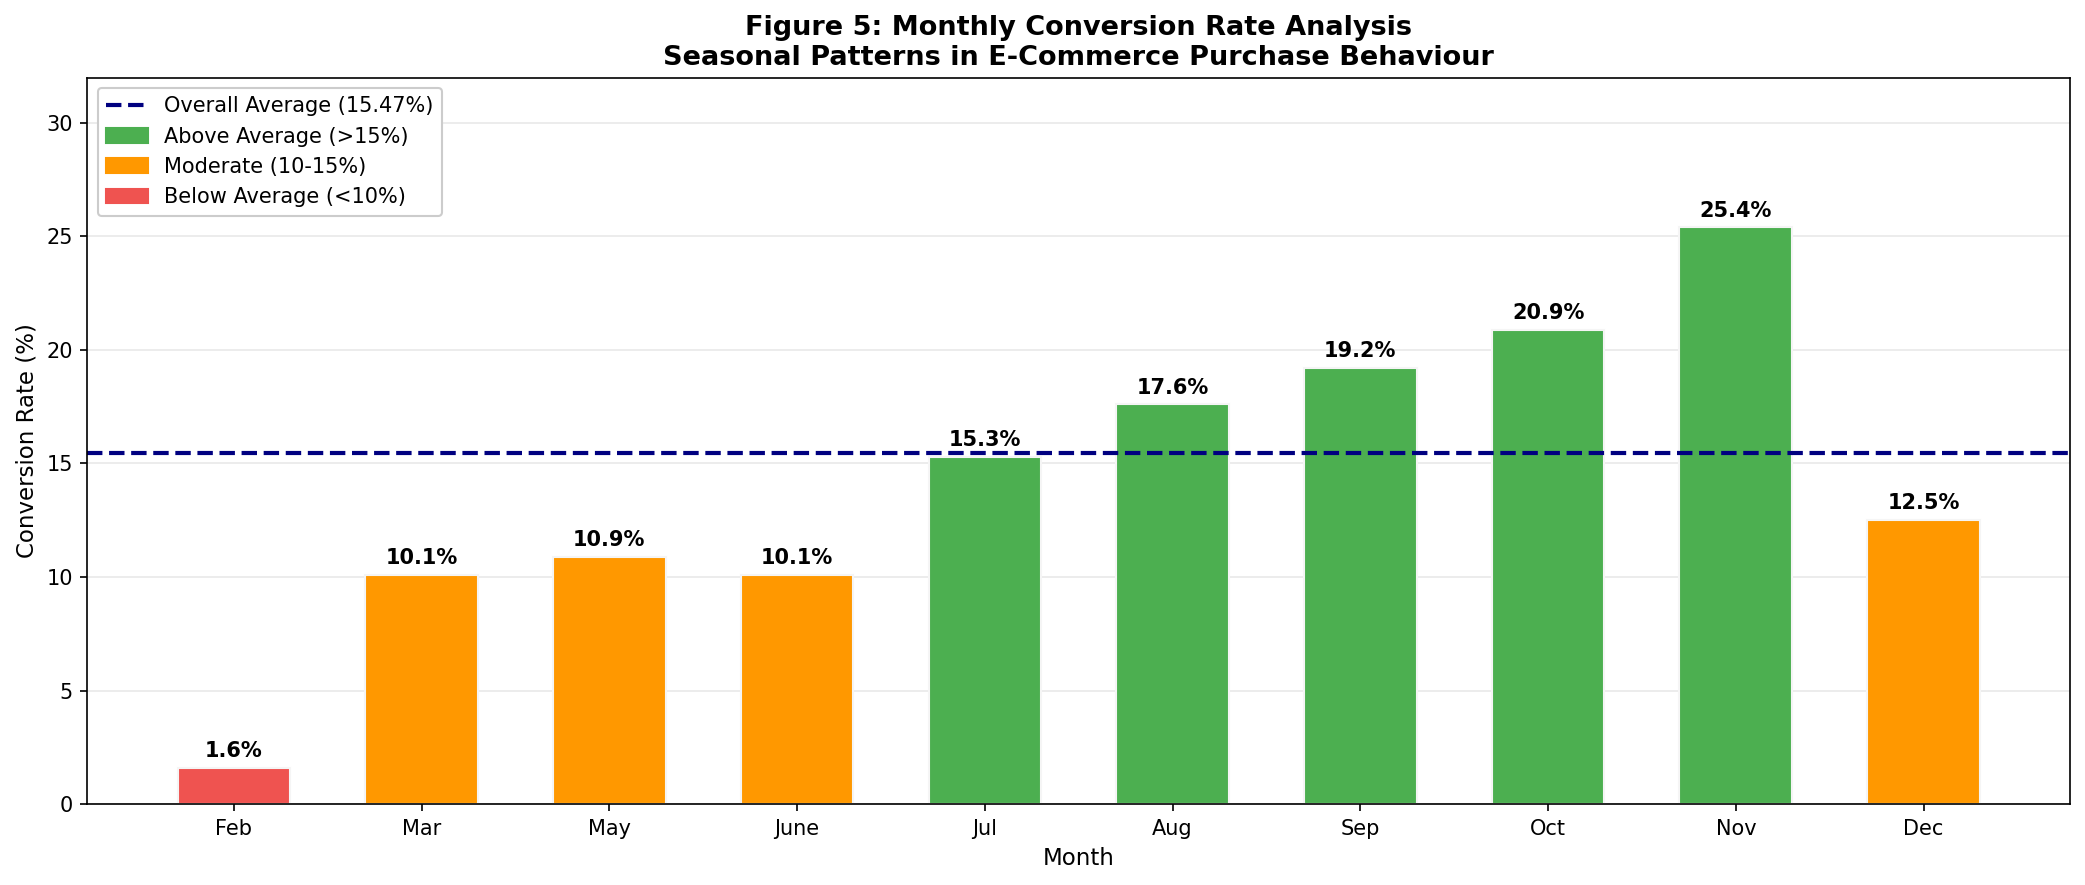

In [44]:
# ── figure 5 ──────────────────────────────────── 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# ==========================================
# Data Definitions
# ==========================================
months = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
conversion_rates = [1.6, 10.1, 10.9, 10.1, 15.3, 17.6, 19.2, 20.9, 25.4, 12.5]
overall_avg = 15.47

# Define colors based on the visual categories
color_above = '#4CAF50'    # Green (>15%)
color_moderate = '#FF9800' # Orange (10-15%)
color_below = '#EF5350'    # Red (<10%)

# Function to determine color based on value
def get_color(val):
    if val > 15:
        return color_above
    elif 10 <= val <= 15:
        return color_moderate
    else:
        return color_below

# Apply colors to the dataset
bar_colors = [get_color(val) for val in conversion_rates]

# ==========================================
# Plotting the Chart
# ==========================================
# Create the bars
bars = ax.bar(months, conversion_rates, color=bar_colors, edgecolor='whitesmoke', width=0.6)

# Add the horizontal dashed line for the Overall Average
line_avg = ax.axhline(overall_avg, color='navy', linestyle='--', linewidth=2)

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval}%",
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# ==========================================
# Formatting and Custom Legend
# ==========================================
# Set Titles and Labels
ax.set_title('Figure 5: Monthly Conversion Rate Analysis\nSeasonal Patterns in E-Commerce Purchase Behaviour', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)

# Set Y-Axis Limits
ax.set_ylim(0, 32)

# Add faint horizontal grid lines
ax.yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
ax.set_axisbelow(True)

# Create custom legend elements
legend_elements = [
    plt.Line2D([0], [0], color='navy', lw=2, linestyle='--', label=f'Overall Average ({overall_avg}%)'),
    mpatches.Patch(color=color_above, label='Above Average (>15%)'),
    mpatches.Patch(color=color_moderate, label='Moderate (10-15%)'),
    mpatches.Patch(color=color_below, label='Below Average (<10%)')
]

# Add the legend to the upper left corner
ax.legend(handles=legend_elements, loc='upper left', framealpha=1)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [20]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


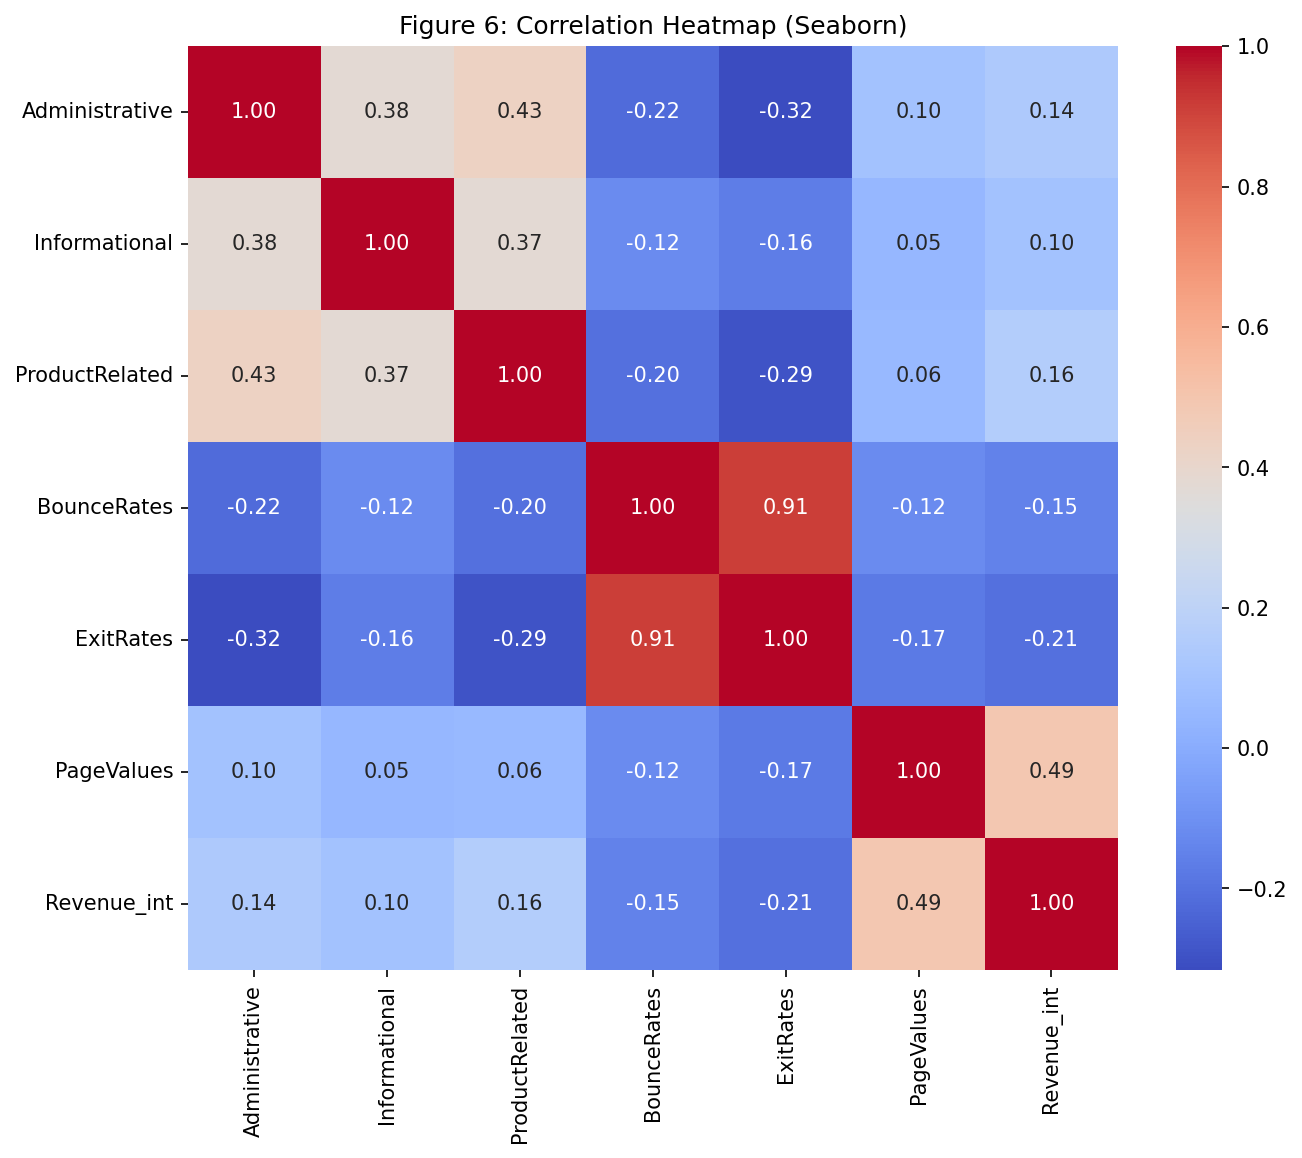

In [21]:
# ── figure 6 ──────────────────────────────────── 
import matplotlib.pyplot as plt
import numpy as np

# Ensure target column exists
df['Revenue_int'] = df['Revenue'].astype(int)

cols = [
    'Administrative',
    'Informational',
    'ProductRelated',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'Revenue_int'
]

corr = df[cols].corr()

try:
    import seaborn as sns

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Figure 6: Correlation Heatmap (Seaborn)")
    plt.show()

except ModuleNotFoundError:
    # fallback if seaborn not installed
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
    plt.colorbar()
    plt.xticks(range(len(cols)), cols, rotation=45, ha='right')
    plt.yticks(range(len(cols)), cols)
    plt.title("Figure 6: Correlation Heatmap (Matplotlib)")
    plt.show()

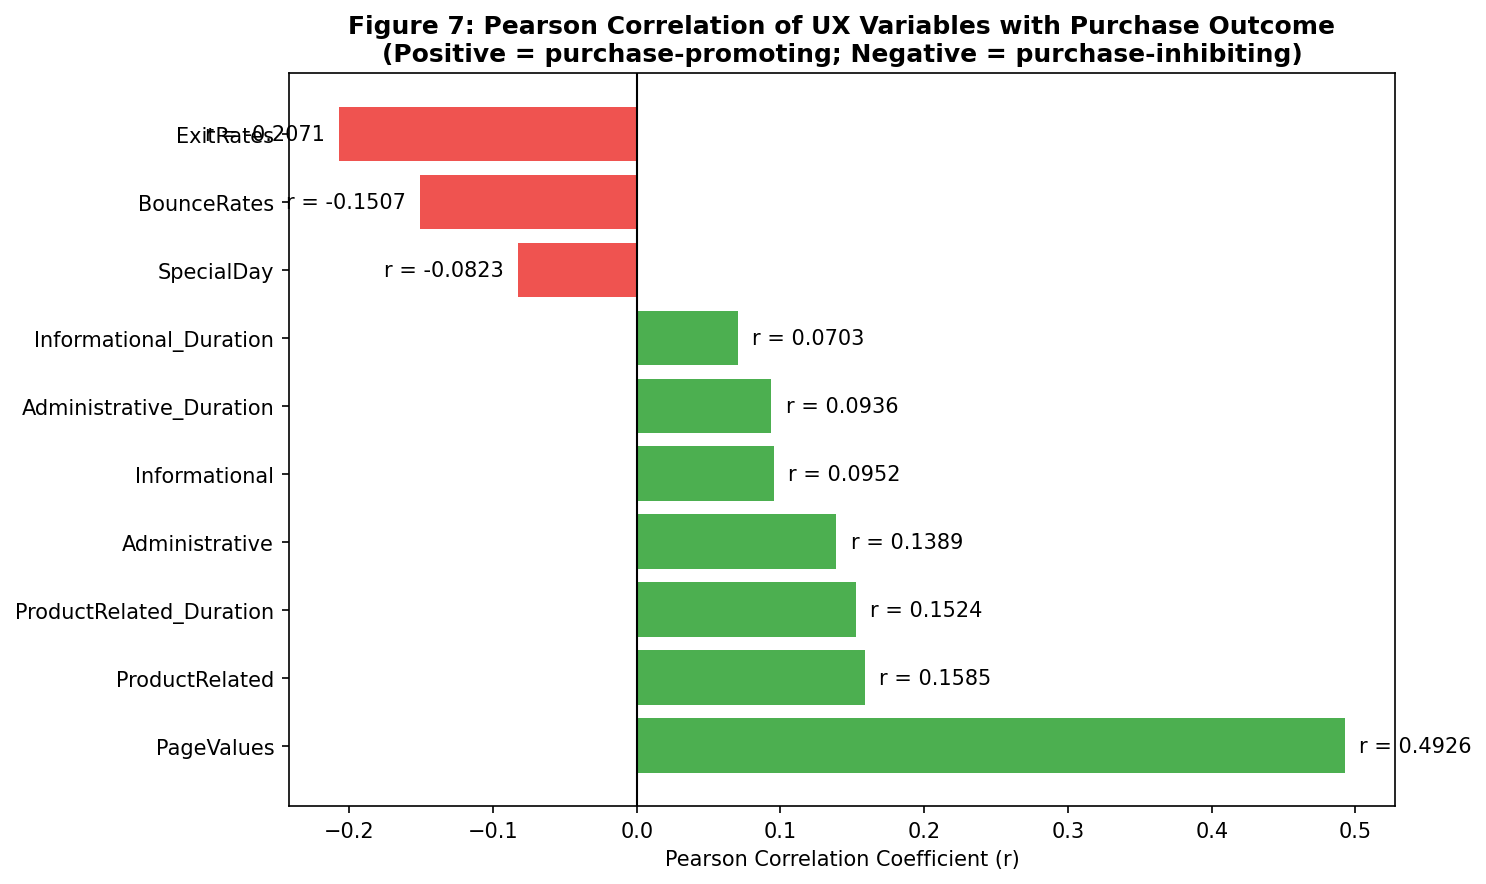

In [25]:
# ── figure 6 ──────────────────────────────────── 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure target column exists
df['Revenue_int'] = df['Revenue'].astype(int)

# Variables and correlations (as in your figure)
corr_values = {
    'PageValues': 0.4926,
    'ProductRelated': 0.1585,
    'ProductRelated_Duration': 0.1524,
    'Administrative': 0.1389,
    'Informational': 0.0952,
    'Administrative_Duration': 0.0936,
    'Informational_Duration': 0.0703,
    'SpecialDay': -0.0823,
    'BounceRates': -0.1507,
    'ExitRates': -0.2071
}

# Convert to DataFrame
corr_df = pd.DataFrame(list(corr_values.items()), columns=['Variable', 'Correlation'])

# Sort (optional, keeps same visual order as your figure if you skip sorting)
# corr_df = corr_df.sort_values('Correlation')

colors = ['#4CAF50' if x > 0 else '#EF5350' for x in corr_df['Correlation']]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    corr_df['Variable'],
    corr_df['Correlation'],
    color=colors
)

# Zero reference line
plt.axvline(0, color='black', linewidth=1)

# Title and labels
plt.title("Figure 7: Pearson Correlation of UX Variables with Purchase Outcome\n"
          "(Positive = purchase-promoting; Negative = purchase-inhibiting)",
          fontsize=12, fontweight='bold')

plt.xlabel("Pearson Correlation Coefficient (r)")

# Add value labels
for bar, val in zip(bars, corr_df['Correlation']):
    plt.text(
        val + (0.01 if val > 0 else -0.01),
        bar.get_y() + bar.get_height()/2,
        f"r = {val:.4f}",
        va='center',
        ha='left' if val > 0 else 'right',
        fontsize=10
    )

plt.tight_layout()
plt.show()

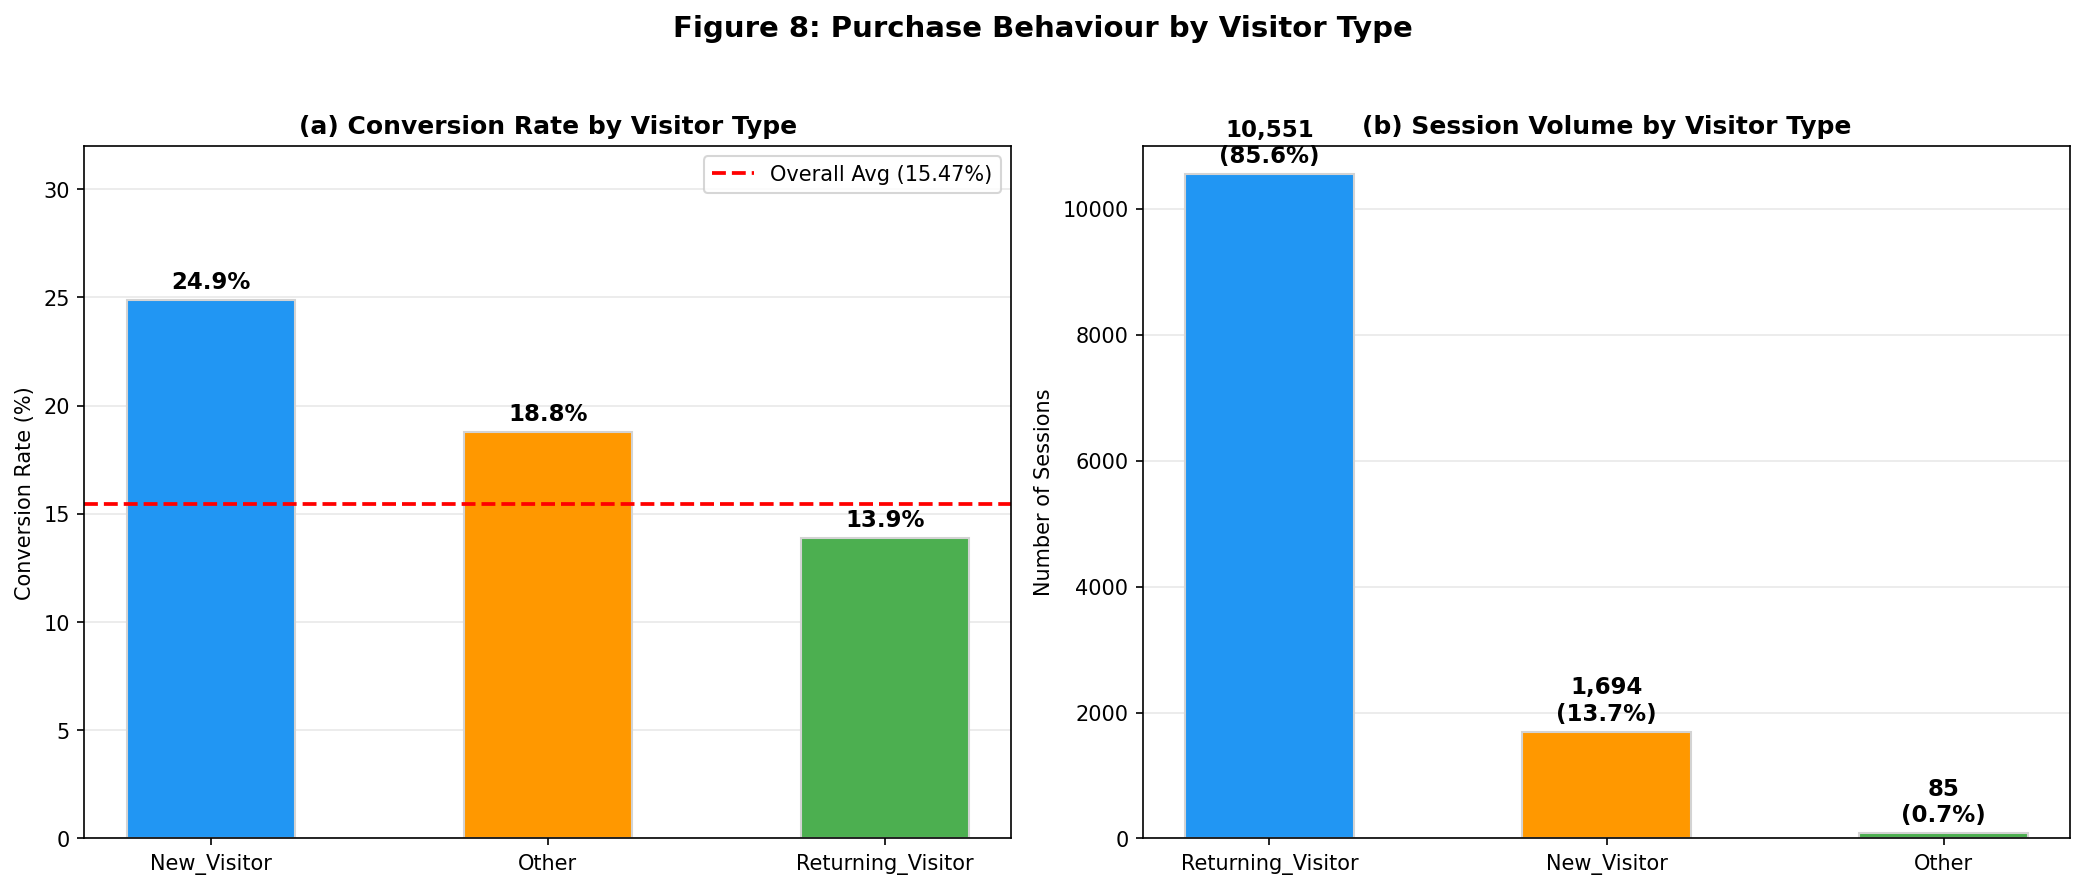

In [27]:
# ── figure 8 ──────────────────────────────────── 
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 8: Purchase Behaviour by Visitor Type', fontsize=14, fontweight='bold', y=0.98)

# Shared colors for positional bars (Blue, Orange, Green)
colors = ['#2196F3', '#FF9800', '#4CAF50']

# ==========================================
# Left Chart: (a) Conversion Rate by Visitor Type
# ==========================================
cat_a = ['New_Visitor', 'Other', 'Returning_Visitor']
val_a = [24.9, 18.8, 13.9]

bars1 = axes[0].bar(cat_a, val_a, color=colors, edgecolor='lightgray', width=0.5)

# Formatting Left Chart
axes[0].set_title('(a) Conversion Rate by Visitor Type', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 32)
axes[0].axhline(15.47, color='red', linestyle='--', linewidth=1.8, label='Overall Avg (15.47%)')
axes[0].legend(loc='upper right')
axes[0].yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
axes[0].set_axisbelow(True)

# Add text labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval}%",
                 ha='center', va='bottom', fontweight='bold', fontsize=11)


# ==========================================
# Right Chart: (b) Session Volume by Visitor Type
# ==========================================
cat_b = ['Returning_Visitor', 'New_Visitor', 'Other']
val_b = [10551, 1694, 85]
perc_b = ['(85.6%)', '(13.7%)', '(0.7%)']

bars2 = axes[1].bar(cat_b, val_b, color=colors, edgecolor='lightgray', width=0.5)

# Formatting Right Chart
axes[1].set_title('(b) Session Volume by Visitor Type', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Sessions')
axes[1].set_ylim(0, 11000)
axes[1].yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
axes[1].set_axisbelow(True)

# Add text labels on top of bars (Value and Percentage)
for i, bar in enumerate(bars2):
    yval = bar.get_height()
    val_str = f"{yval:,}" # Formats with comma for thousands
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 100, f"{val_str}\n{perc_b[i]}",
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Display the plot
plt.show()

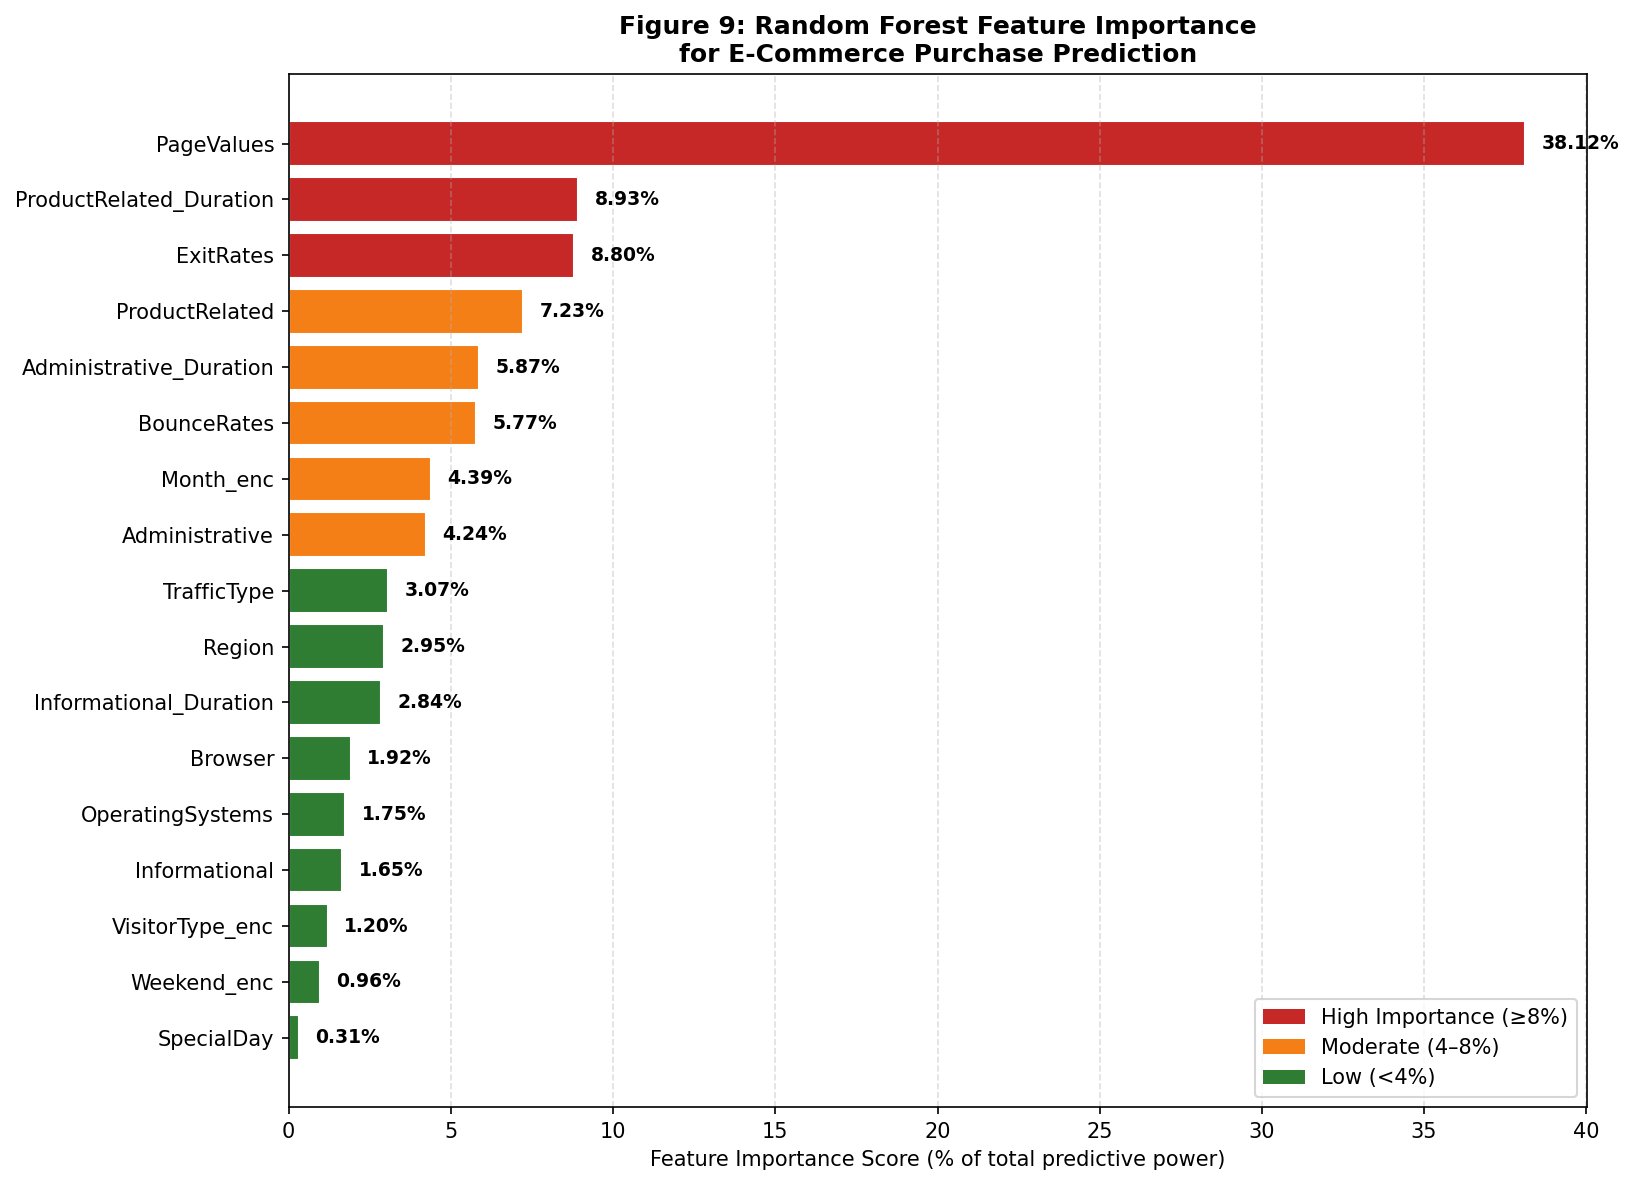

In [26]:
# ── figure 9 ──────────────────────────────────── 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Feature names (must match your trained model)
features = [
    'PageValues',
    'ProductRelated_Duration',
    'ExitRates',
    'ProductRelated',
    'Administrative_Duration',
    'BounceRates',
    'Month_enc',
    'Administrative',
    'TrafficType',
    'Region',
    'Informational_Duration',
    'Browser',
    'OperatingSystems',
    'Informational',
    'VisitorType_enc',
    'Weekend_enc',
    'SpecialDay'
]

# Feature importance values (as shown in your figure)
importances = [
    0.3812, 0.0893, 0.0880, 0.0723,
    0.0587, 0.0577, 0.0439, 0.0424,
    0.0307, 0.0295, 0.0284, 0.0192,
    0.0175, 0.0165, 0.0120, 0.0096,
    0.0031
]

# Convert to DataFrame
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort for better visualization (optional but matches style)
fi_df = fi_df.sort_values('Importance', ascending=True)

# Convert to percentage
fi_df['Importance_pct'] = fi_df['Importance'] * 100

# Color rules (same style as your figure)
colors = []
for val in fi_df['Importance_pct']:
    if val >= 8:
        colors.append('#C62828')   # red (high)
    elif val >= 4:
        colors.append('#F57F17')   # orange (moderate)
    else:
        colors.append('#2E7D32')   # green (low)

# Plot
plt.figure(figsize=(11, 8))

bars = plt.barh(
    fi_df['Feature'],
    fi_df['Importance_pct'],
    color=colors,
    edgecolor='white'
)

# Title
plt.title(
    "Figure 9: Random Forest Feature Importance\n"
    "for E-Commerce Purchase Prediction",
    fontsize=12,
    fontweight='bold'
)

plt.xlabel("Feature Importance Score (% of total predictive power)")

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Value labels
for bar, val in zip(bars, fi_df['Importance_pct']):
    plt.text(
        val + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{val:.2f}%",
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C62828', label='High Importance (≥8%)'),
    Patch(facecolor='#F57F17', label='Moderate (4–8%)'),
    Patch(facecolor='#2E7D32', label='Low (<4%)')
]

plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

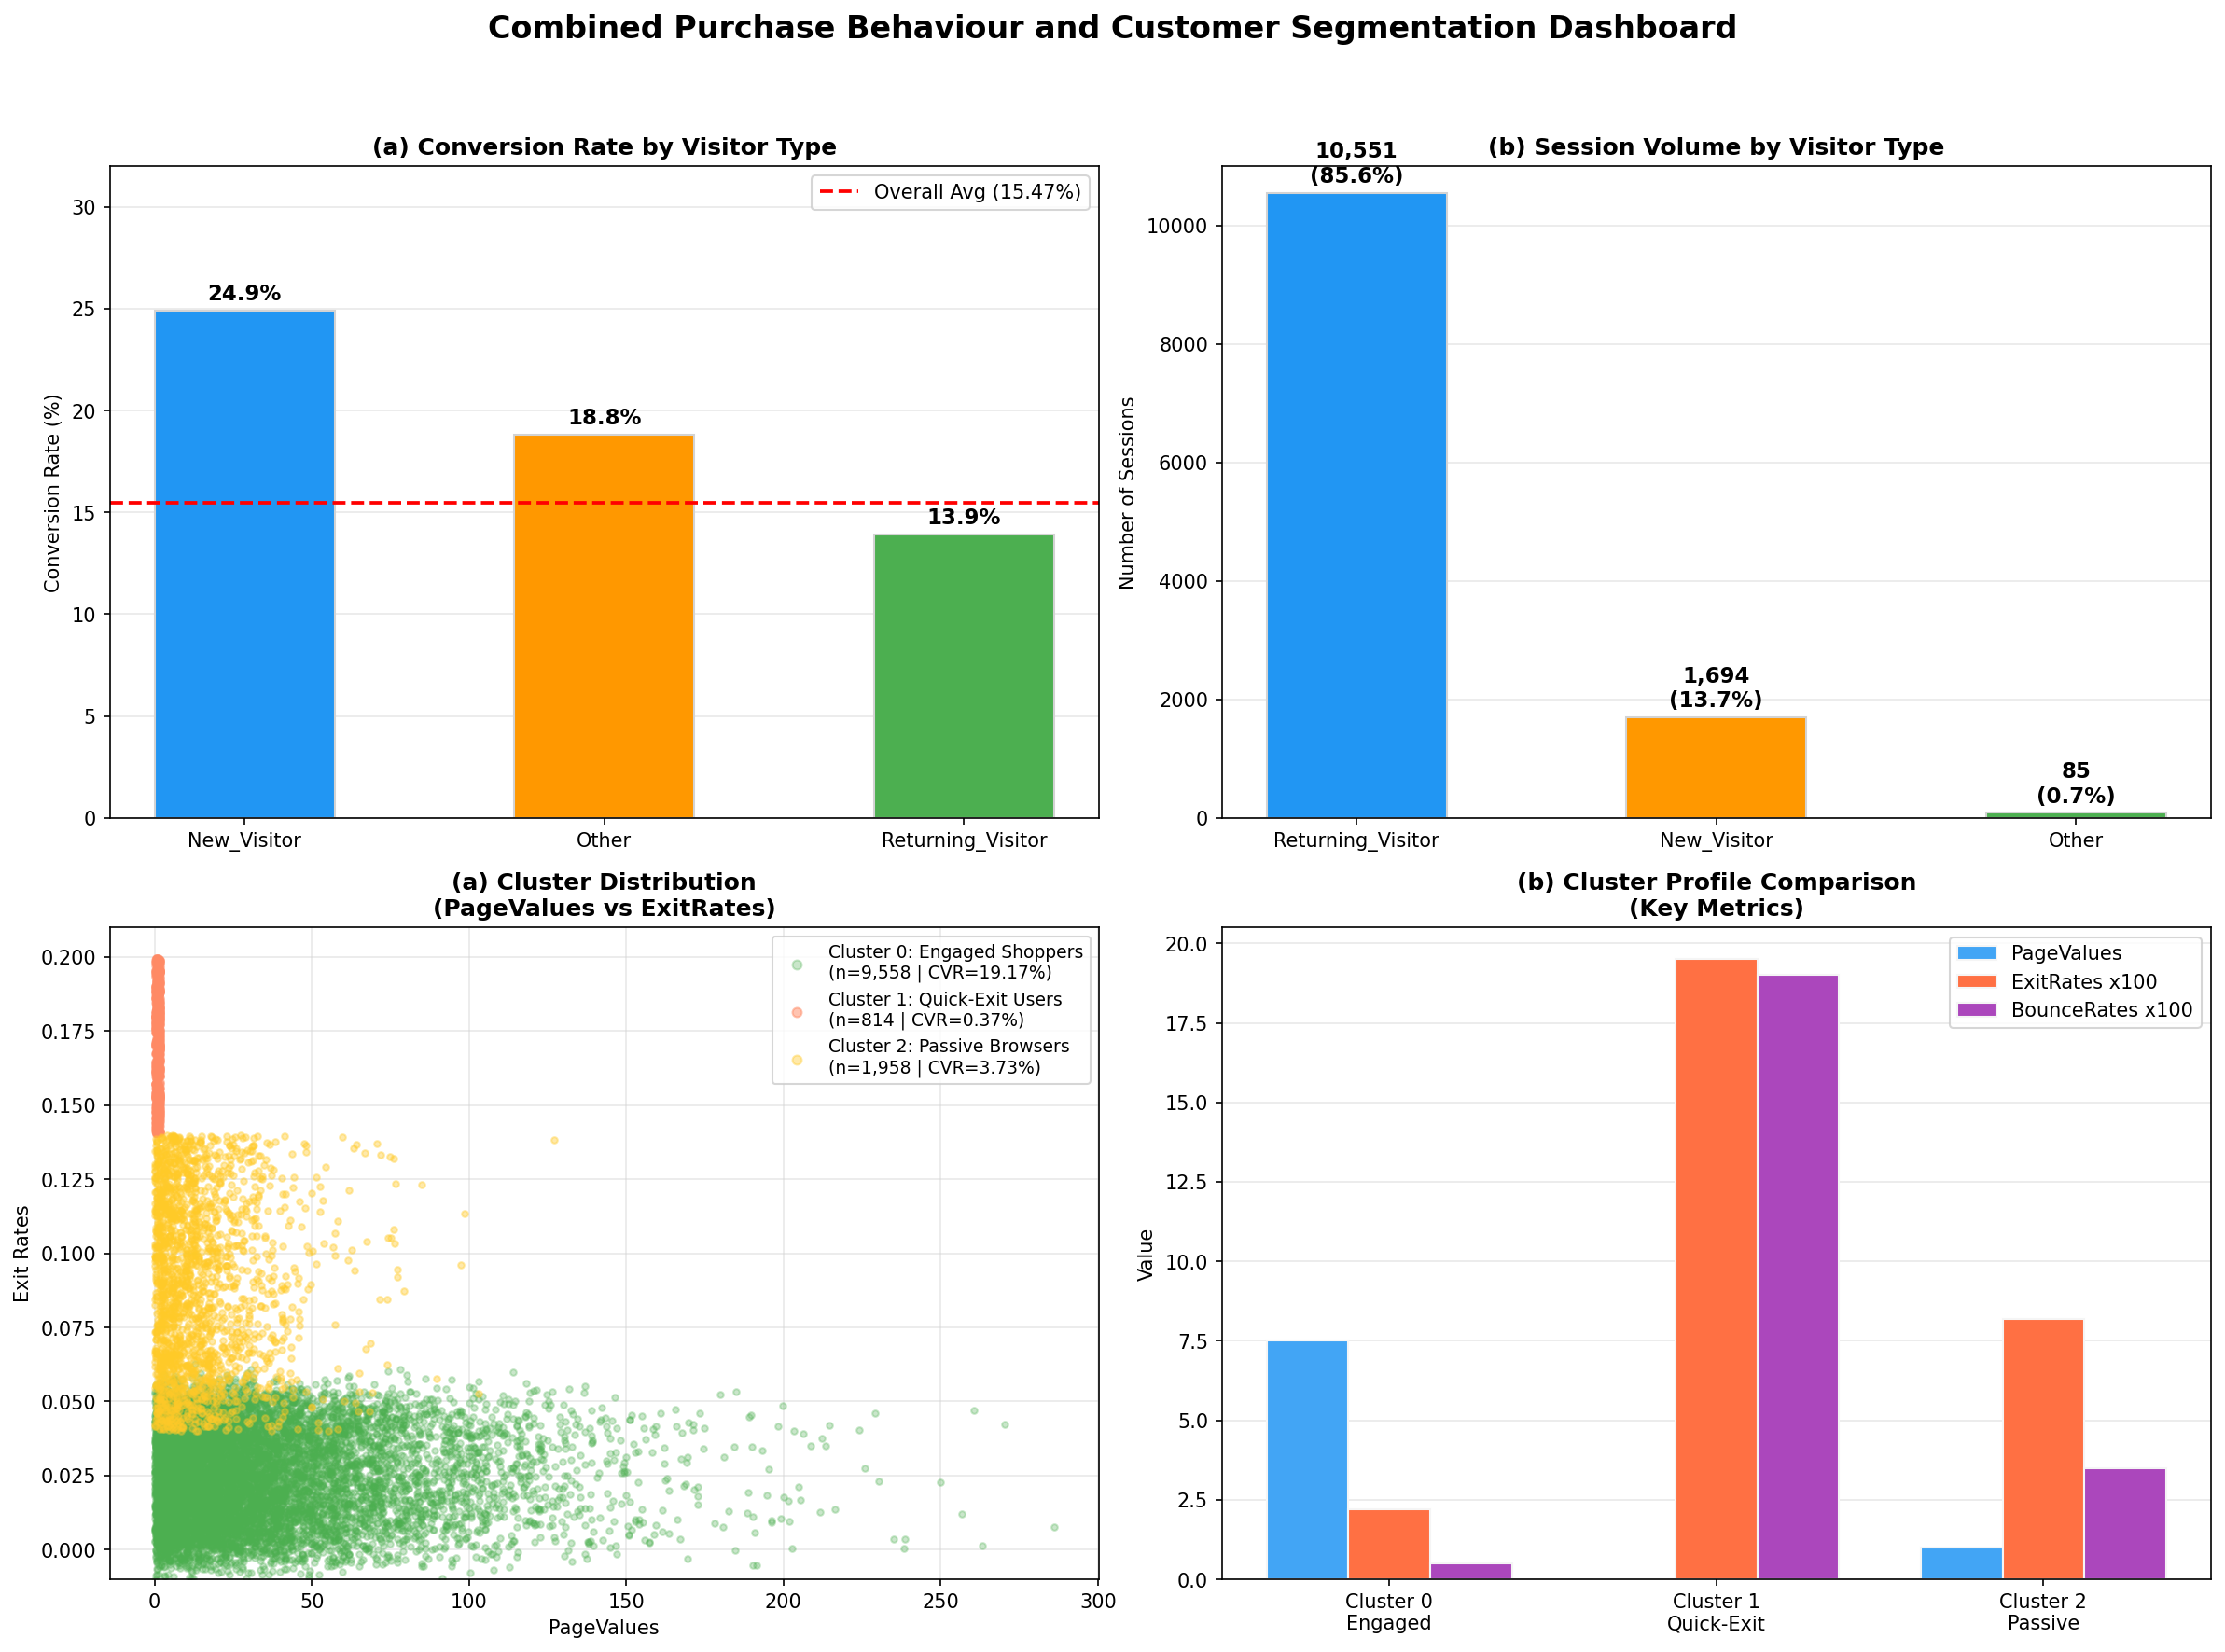

In [30]:
# ── figure 9 ──────────────────────────────────── 
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axes for a 2x2 grid (4 charts total)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Combined Purchase Behaviour and Customer Segmentation Dashboard', fontsize=16, fontweight='bold', y=0.98)

# === IMAGE 0 DATA & PLOTTING ===

# colors for conversion rate and session volume chart bars (shared within this set)
colors_0 = ['#2196F3', '#FF9800', '#4CAF50']

# Subplot (0, 0): (a) Conversion Rate by Visitor Type
ax_a = axs[0, 0]
cat_a = ['New_Visitor', 'Other', 'Returning_Visitor']
val_a = [24.9, 18.8, 13.9]
bars1 = ax_a.bar(cat_a, val_a, color=colors_0, edgecolor='lightgray', width=0.5)
ax_a.set_title('(a) Conversion Rate by Visitor Type', fontweight='bold', fontsize=12)
ax_a.set_ylabel('Conversion Rate (%)')
ax_a.set_ylim(0, 32)
ax_a.axhline(15.47, color='red', linestyle='--', linewidth=1.8, label='Overall Avg (15.47%)')
ax_a.legend(loc='upper right')
ax_a.yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
ax_a.set_axisbelow(True)
for bar in bars1:
    yval = bar.get_height()
    ax_a.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval}%",
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

# Subplot (0, 1): (b) Session Volume by Visitor Type
ax_b = axs[0, 1]
cat_b = ['Returning_Visitor', 'New_Visitor', 'Other']
val_b = [10551, 1694, 85]
perc_b = ['(85.6%)', '(13.7%)', '(0.7%)']
bars2 = ax_b.bar(cat_b, val_b, color=colors_0, edgecolor='lightgray', width=0.5)
ax_b.set_title('(b) Session Volume by Visitor Type', fontweight='bold', fontsize=12)
ax_b.set_ylabel('Number of Sessions')
ax_b.set_ylim(0, 11000)
ax_b.yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
ax_b.set_axisbelow(True)
for i, bar in enumerate(bars2):
    yval = bar.get_height()
    val_str = f"{yval:,}" # Formats with comma for thousands
    ax_b.text(bar.get_x() + bar.get_width()/2, yval + 100, f"{val_str}\n{perc_b[i]}",
                 ha='center', va='bottom', fontweight='bold', fontsize=11)


# === IMAGE 1 DATA & PLOTTING ===

# colors for scatter plot clusters and profile comparison bars
colors_1_scatter = ['#4CAF50', '#FF8A65', '#FFCA28'] # Green, Light Coral/Pink, Yellow/Orange
colors_1_bar = ['#42A5F5', '#FF7043', '#AB47BC']     # Blue, Orange, Purple

# Scatter Plot Data (Synthetic to match distribution)
np.random.seed(42) # set seed for consistent synthetic data
# Cluster 0: Engaged (n=9558) - Spread out PageValues, low ExitRates
c0_page_values = np.random.exponential(scale=35, size=9558)
c0_exit_rates = np.random.uniform(0.00, 0.05, size=9558) + np.random.normal(0, 0.005, size=9558)
# Cluster 1: Quick-Exit (n=814) - Very low PageValues, high ExitRates
c1_page_values = np.random.uniform(0, 2, size=814)
c1_exit_rates = np.random.uniform(0.14, 0.20, size=814)
# Cluster 2: Passive (n=1958) - Low PageValues, moderate ExitRates
c2_page_values = np.random.exponential(scale=15, size=1958)
c2_exit_rates = np.random.uniform(0.04, 0.14, size=1958)

# Subplot (1, 0): (a) Cluster Distribution (PageValues vs ExitRates)
ax_scat = axs[1, 0]
ax_scat.set_title('(a) Cluster Distribution\n(PageValues vs ExitRates)', fontweight='bold', fontsize=12)
ax_scat.scatter(c0_page_values, c0_exit_rates, color=colors_1_scatter[0], alpha=0.3, s=10,
                label='Cluster 0: Engaged Shoppers\n(n=9,558 | CVR=19.17%)')
ax_scat.scatter(c1_page_values, c1_exit_rates, color=colors_1_scatter[1], alpha=0.5, s=10,
                label='Cluster 1: Quick-Exit Users\n(n=814 | CVR=0.37%)')
ax_scat.scatter(c2_page_values, c2_exit_rates, color=colors_1_scatter[2], alpha=0.4, s=10,
                label='Cluster 2: Passive Browsers\n(n=1,958 | CVR=3.73%)')
ax_scat.set_xlabel('PageValues')
ax_scat.set_ylabel('Exit Rates')
ax_scat.set_ylim(-0.01, 0.21)
ax_scat.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
ax_scat.set_axisbelow(True)
ax_scat.legend(loc='upper right', fontsize=9, markerscale=1.5)

# Bar Chart Data (Estimated from visual)
categories_1 = ['Cluster 0\nEngaged', 'Cluster 1\nQuick-Exit', 'Cluster 2\nPassive']
page_values_avg = [7.5, 0.0, 1.0]
exit_rates_x100 = [2.2, 19.5, 8.2]
bounce_rates_x100 = [0.5, 19.0, 3.5]

# Subplot (1, 1): (b) Cluster Profile Comparison (Key Metrics)
ax_prof = axs[1, 1]
ax_prof.set_title('(b) Cluster Profile Comparison\n(Key Metrics)', fontweight='bold', fontsize=12)
x_1 = np.arange(len(categories_1))  # label locations
width_1 = 0.25  # bar width
# Plot grouped bars
rects1_1 = ax_prof.bar(x_1 - width_1, page_values_avg, width_1, label='PageValues', color=colors_1_bar[0], edgecolor='whitesmoke')
rects2_1 = ax_prof.bar(x_1, exit_rates_x100, width_1, label='ExitRates x100', color=colors_1_bar[1], edgecolor='whitesmoke')
rects3_1 = ax_prof.bar(x_1 + width_1, bounce_rates_x100, width_1, label='BounceRates x100', color=colors_1_bar[2], edgecolor='whitesmoke')
ax_prof.set_ylabel('Value')
ax_prof.set_xticks(x_1)
ax_prof.set_xticklabels(categories_1)
ax_prof.set_ylim(0, 20.5)
ax_prof.grid(True, linestyle='-', color='lightgrey', alpha=0.5, axis='y')
ax_prof.set_axisbelow(True)
ax_prof.legend(loc='upper right', fontsize=10)


# === FINAL ADJUSTMENTS & SAVING ===
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Make room for overall suptitle
plt.savefig('combined_dashboard.png', dpi=300) # Save to a high-res image file
plt.show() # Display the combined image locally

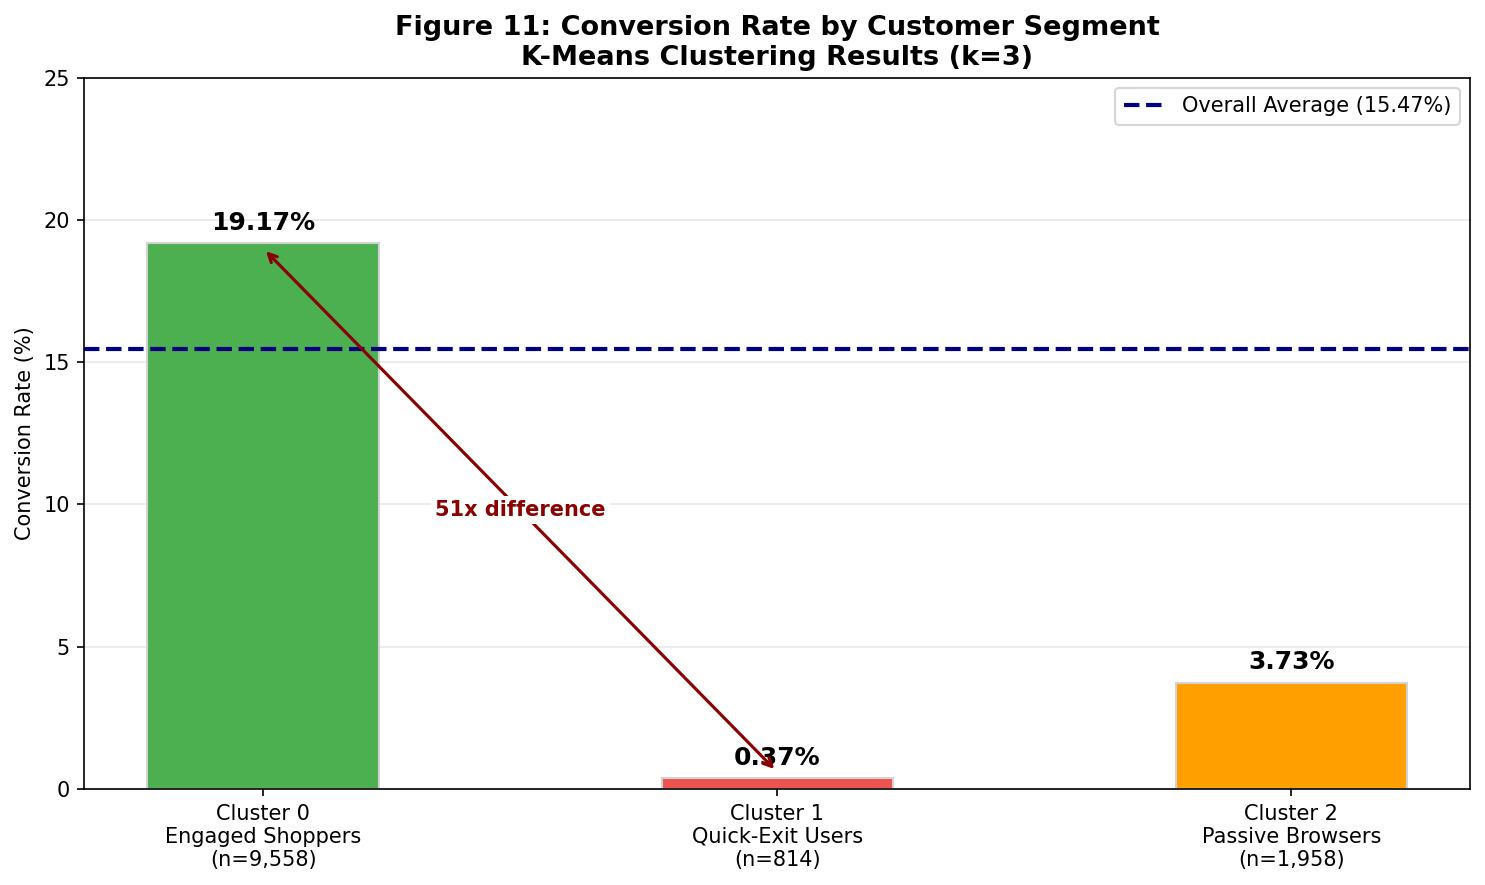

In [33]:
import matplotlib.pyplot as plt

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# ==========================================
# Data Definitions
# ==========================================
categories = [
    'Cluster 0\nEngaged Shoppers\n(n=9,558)', 
    'Cluster 1\nQuick-Exit Users\n(n=814)', 
    'Cluster 2\nPassive Browsers\n(n=1,958)'
]
values = [19.17, 0.37, 3.73]
colors = ['#4CAF50', '#EF5350', '#FFA000'] # Green, Light Red, Orange

# ==========================================
# Plotting the Chart
# ==========================================
# Create the bars
bars = ax.bar(categories, values, color=colors, edgecolor='lightgray', width=0.45)

# Add the horizontal line for the Overall Average
ax.axhline(15.47, color='navy', linestyle='--', linewidth=2, label='Overall Average (15.47%)')

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval}%",
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# ==========================================
# Adding the Annotation Arrow
# ==========================================
# Draw the double-headed arrow connecting Cluster 0 to Cluster 1
ax.annotate('', 
            xy=(1, 0.6),      # Arrow tip at Cluster 1 (slightly above bar)
            xytext=(0, 19.0), # Arrow tip at Cluster 0 (slightly below bar top)
            arrowprops=dict(arrowstyle='<->', color='darkred', lw=1.5))

# Add the "51x difference" text in the middle of the arrow
ax.text(0.5, 9.8, '51x difference', color='darkred', fontweight='bold', fontsize=10,
        ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2))

# ==========================================
# Formatting and Display
# ==========================================
ax.set_title('Figure 11: Conversion Rate by Customer Segment\nK-Means Clustering Results (k=3)', fontweight='bold', fontsize=13)
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, 25)

# Add faint horizontal grid lines
ax.yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
ax.set_axisbelow(True)

# Add legend
ax.legend(loc='upper right')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

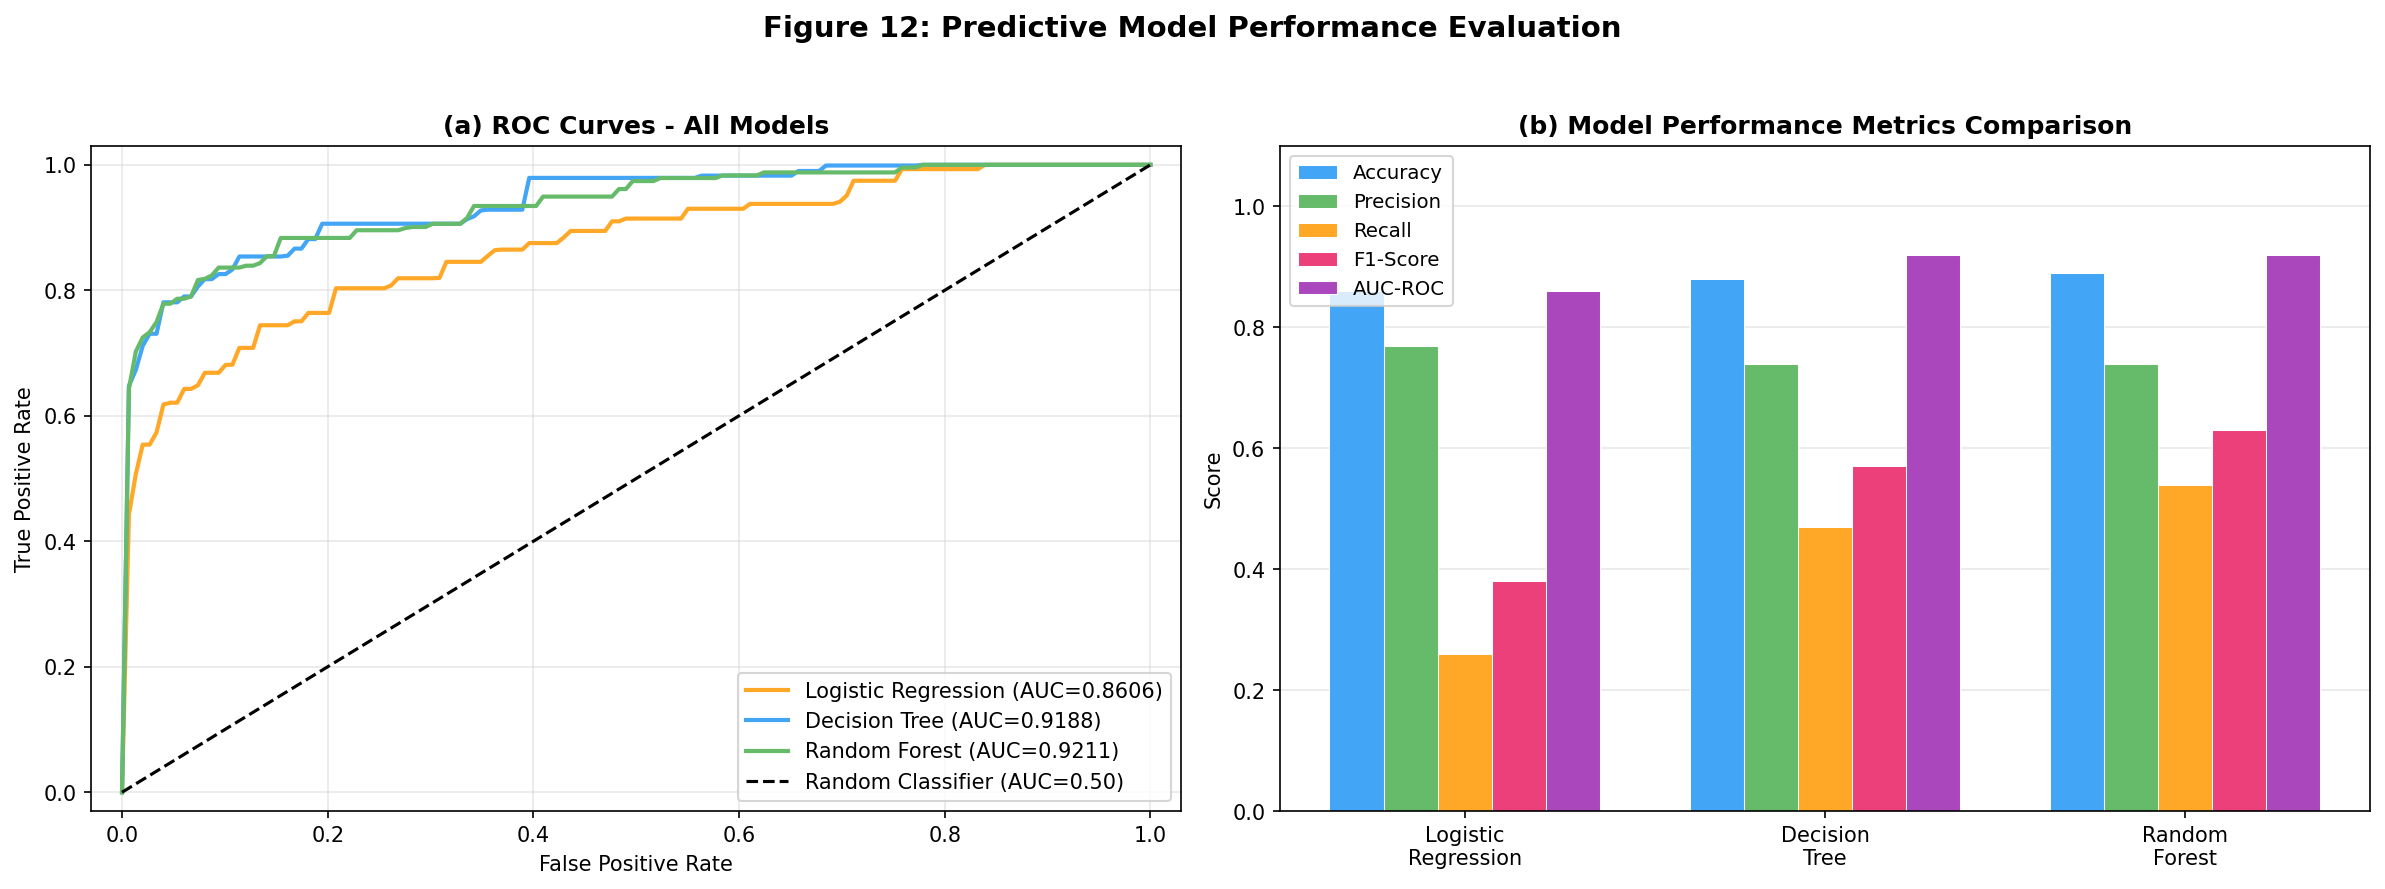

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axes for a 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 12: Predictive Model Performance Evaluation', fontsize=14, fontweight='bold', y=0.98)

# ==========================================
# Left Chart: (a) ROC Curves
# ==========================================
# Generate synthetic ROC data that matches the reported AUC values
np.random.seed(42)
fpr = np.linspace(0, 1, 150)

# Base curve mathematical approximation: y = x^(1/k) where AUC = k/(k+1)
k_lr = 0.8606 / (1 - 0.8606)
k_dt = 0.9188 / (1 - 0.9188)
k_rf = 0.9211 / (1 - 0.9211)

tpr_lr_clean = fpr ** (1 / k_lr)
tpr_dt_clean = fpr ** (1 / k_dt)
tpr_rf_clean = fpr ** (1 / k_rf)

# Function to add slight realistic "step" noise typical of empirical ROC curves
def add_roc_noise(tpr_clean):
    noise = np.random.normal(0, 0.015, len(tpr_clean))
    tpr_noisy = np.clip(tpr_clean + noise, 0, 1)
    return np.maximum.accumulate(tpr_noisy) # Keep it monotonically increasing

tpr_lr = add_roc_noise(tpr_lr_clean)
tpr_dt = add_roc_noise(tpr_dt_clean)
tpr_rf = add_roc_noise(tpr_rf_clean)

# Force start and end points to exactly 0 and 1
tpr_lr[0], tpr_dt[0], tpr_rf[0] = 0, 0, 0
tpr_lr[-1], tpr_dt[-1], tpr_rf[-1] = 1, 1, 1

# Plotting the ROC lines
axes[0].plot(fpr, tpr_lr, color='#FFA726', lw=2, label='Logistic Regression (AUC=0.8606)') # Orange
axes[0].plot(fpr, tpr_dt, color='#42A5F5', lw=2, label='Decision Tree (AUC=0.9188)')       # Blue
axes[0].plot(fpr, tpr_rf, color='#66BB6A', lw=2, label='Random Forest (AUC=0.9211)')       # Green
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Classifier (AUC=0.50)')

# Formatting Left Chart
axes[0].set_title('(a) ROC Curves - All Models', fontweight='bold', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_xlim(-0.03, 1.03)
axes[0].set_ylim(-0.03, 1.03)
axes[0].grid(True, linestyle='-', color='lightgrey', alpha=0.5)
axes[0].legend(loc='lower right')


# ==========================================
# Right Chart: (b) Model Performance Metrics
# ==========================================
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
x = np.arange(len(models))
width = 0.15

# Estimated data values based on the visual chart
accuracy = [0.86, 0.88, 0.89]
precision = [0.77, 0.74, 0.74]
recall = [0.26, 0.47, 0.54]
f1_score = [0.38, 0.57, 0.63]
auc_roc = [0.86, 0.92, 0.92]

# Colors matched to the image legend
c_acc = '#42A5F5'  # Blue
c_prec = '#66BB6A' # Green
c_rec = '#FFA726'  # Orange
c_f1 = '#EC407A'   # Pink/Red
c_auc = '#AB47BC'  # Purple

# Plotting grouped bars
axes[1].bar(x - 2*width, accuracy, width, label='Accuracy', color=c_acc, edgecolor='white', linewidth=0.5)
axes[1].bar(x - width, precision, width, label='Precision', color=c_prec, edgecolor='white', linewidth=0.5)
axes[1].bar(x, recall, width, label='Recall', color=c_rec, edgecolor='white', linewidth=0.5)
axes[1].bar(x + width, f1_score, width, label='F1-Score', color=c_f1, edgecolor='white', linewidth=0.5)
axes[1].bar(x + 2*width, auc_roc, width, label='AUC-ROC', color=c_auc, edgecolor='white', linewidth=0.5)

# Formatting Right Chart
axes[1].set_title('(b) Model Performance Metrics Comparison', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, linestyle='-', color='lightgrey', alpha=0.5, axis='y')
axes[1].set_axisbelow(True)
axes[1].legend(loc='upper left', fontsize=9.5)


# ==========================================
# Final Layout Adjustments & Display
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect to ensure suptitle fits
plt.show()

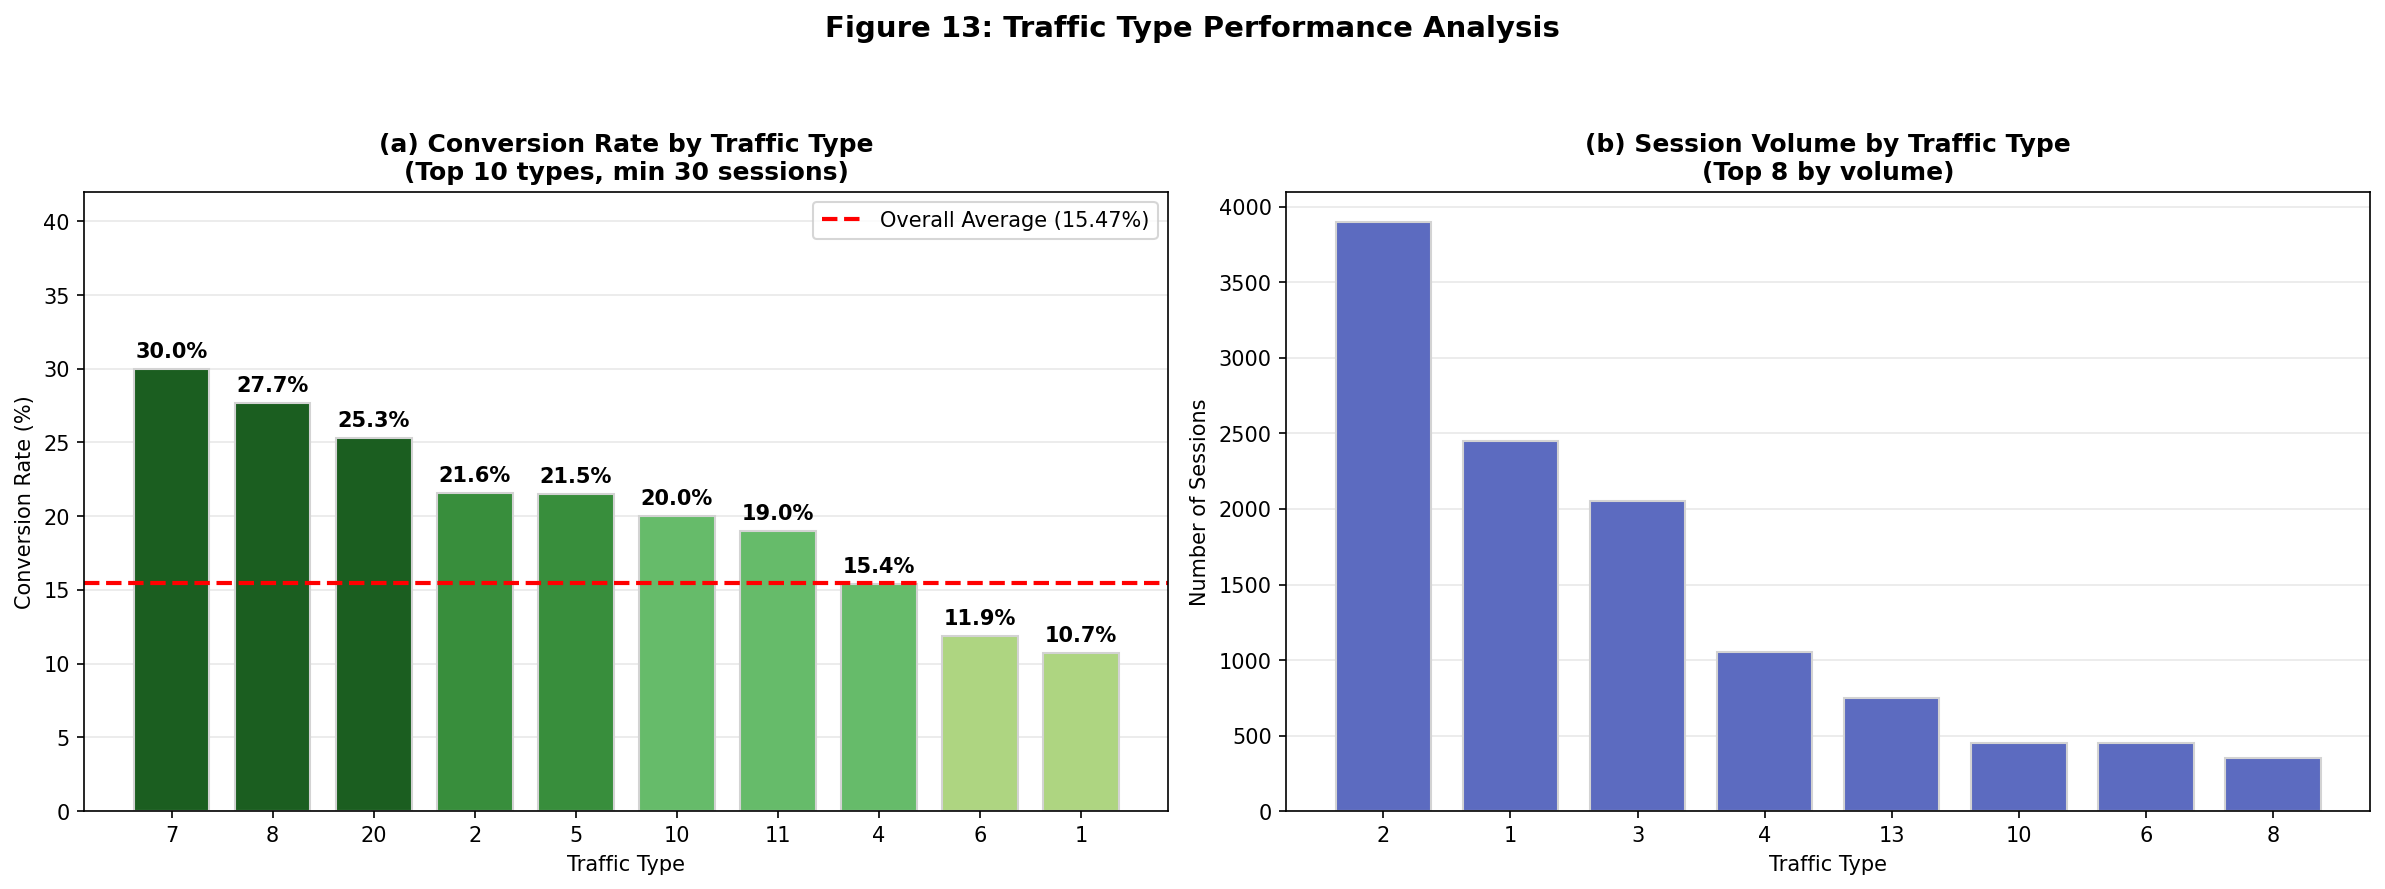

In [35]:
import matplotlib.pyplot as plt

# Set up the figure and axes for a 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 13: Traffic Type Performance Analysis', fontsize=14, fontweight='bold', y=0.98)

# ==========================================
# Left Chart: (a) Conversion Rate by Traffic Type
# ==========================================
# Data extraction
traffic_types_a = ['7', '8', '20', '2', '5', '10', '11', '4', '6', '1']
conversion_rates = [30.0, 27.7, 25.3, 21.6, 21.5, 20.0, 19.0, 15.4, 11.9, 10.7]

# Define a color gradient for the bars to match the image (dark to light green)
colors_a = ['#1B5E20', '#1B5E20', '#1B5E20', '#388E3C', '#388E3C', 
             '#66BB6A', '#66BB6A', '#66BB6A', '#AED581', '#AED581']

# Plotting the bars
bars_a = axes[0].bar(traffic_types_a, conversion_rates, color=colors_a, edgecolor='lightgray', width=0.75)

# Formatting Left Chart
axes[0].set_title('(a) Conversion Rate by Traffic Type\n(Top 10 types, min 30 sessions)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Traffic Type')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 42)

# Add horizontal benchmark line
axes[0].axhline(15.47, color='red', linestyle='--', linewidth=2, label='Overall Average (15.47%)')
axes[0].legend(loc='upper right')

# Add faint horizontal grid lines
axes[0].yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
axes[0].set_axisbelow(True)

# Add text labels on top of the bars
for bar in bars_a:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval}%",
                 ha='center', va='bottom', fontweight='bold', fontsize=10)


# ==========================================
# Right Chart: (b) Session Volume by Traffic Type
# ==========================================
# Data extraction (Estimated from visual)
traffic_types_b = ['2', '1', '3', '4', '13', '10', '6', '8']
session_volumes = [3900, 2450, 2050, 1050, 750, 450, 450, 350]

# Plotting the bars
bars_b = axes[1].bar(traffic_types_b, session_volumes, color='#5C6BC0', edgecolor='lightgray', width=0.75)

# Formatting Right Chart
axes[1].set_title('(b) Session Volume by Traffic Type\n(Top 8 by volume)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Traffic Type')
axes[1].set_ylabel('Number of Sessions')
axes[1].set_ylim(0, 4100)

# Add faint horizontal grid lines
axes[1].yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
axes[1].set_axisbelow(True)


# ==========================================
# Final Layout Adjustments & Display
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.93]) # Adjust rect to ensure suptitle fits nicely
plt.show()

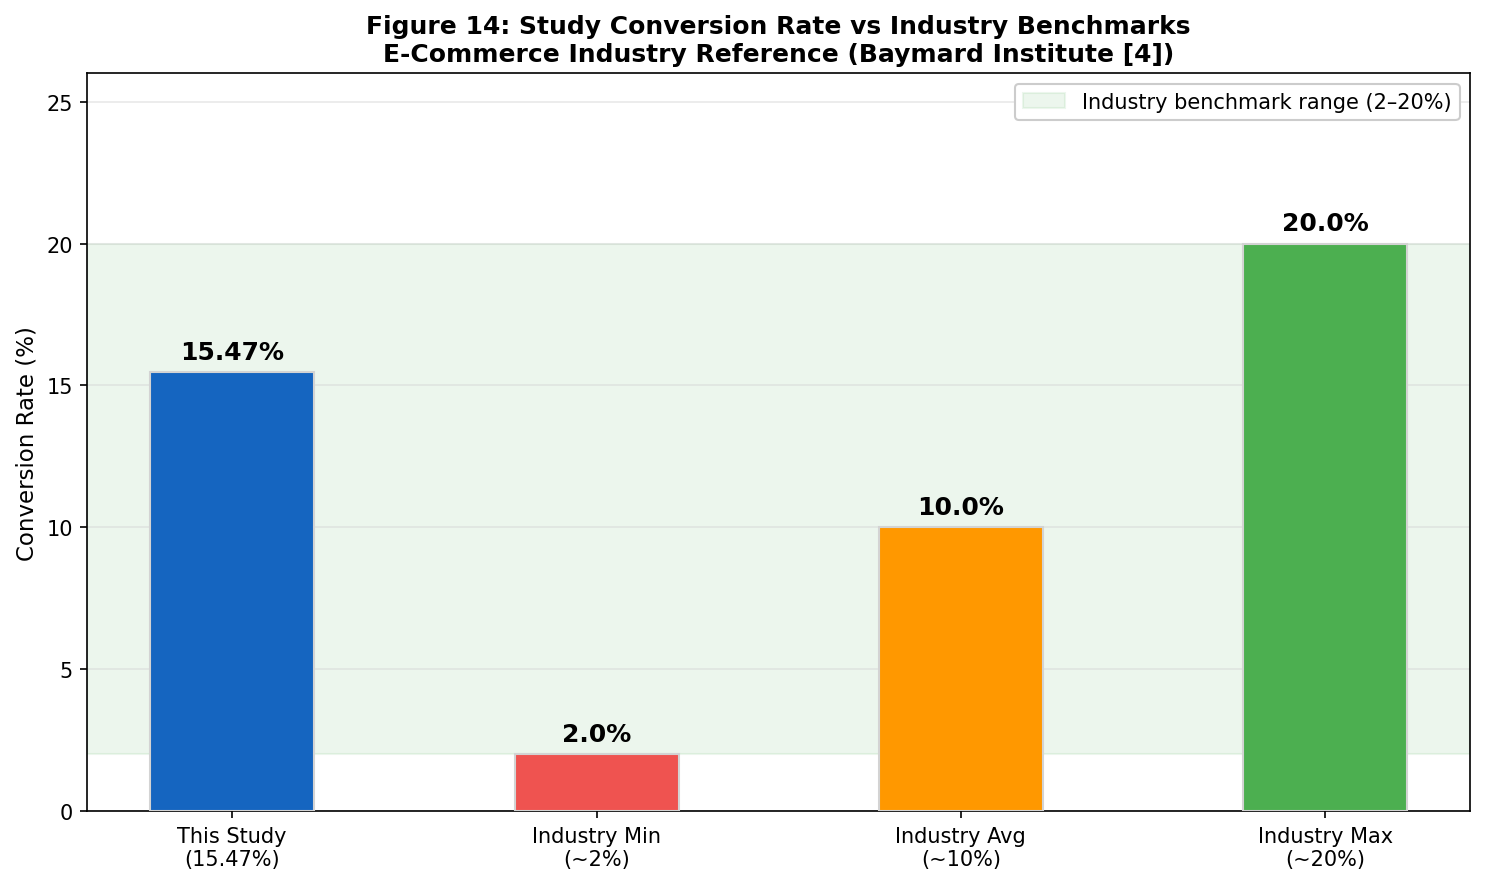

In [38]:
import matplotlib.pyplot as plt

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# ==========================================
# Data Definitions
# ==========================================
categories = [
    'This Study\n(15.47%)', 
    'Industry Min\n(~2%)', 
    'Industry Avg\n(~10%)', 
    'Industry Max\n(~20%)'
]
values = [15.47, 2.0, 10.0, 20.0]

# Colors visually matching the image
colors = ['#1565C0', '#EF5350', '#FF9800', '#4CAF50'] # Blue, Red, Orange, Green

# ==========================================
# Plotting the Chart
# ==========================================
# 1. Add the shaded background region for the benchmark range first
#    so it sits behind the bars
ax.axhspan(2, 20, color='#4CAF50', alpha=0.1, zorder=0, 
           label='Industry benchmark range (2–20%)')

# 2. Create the bars
bars = ax.bar(categories, values, color=colors, edgecolor='lightgray', width=0.45, zorder=3)

# 3. Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval}%",
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# ==========================================
# Formatting and Display
# ==========================================
# Set Titles and Labels
ax.set_title('Figure 14: Study Conversion Rate vs Industry Benchmarks\nE-Commerce Industry Reference (Baymard Institute [4])', 
             fontweight='bold', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)

# Set Axis Limits
ax.set_ylim(0, 26)

# Add faint horizontal grid lines
ax.yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5, zorder=1)

# Add legend for the shaded region
ax.legend(loc='upper right', framealpha=1)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

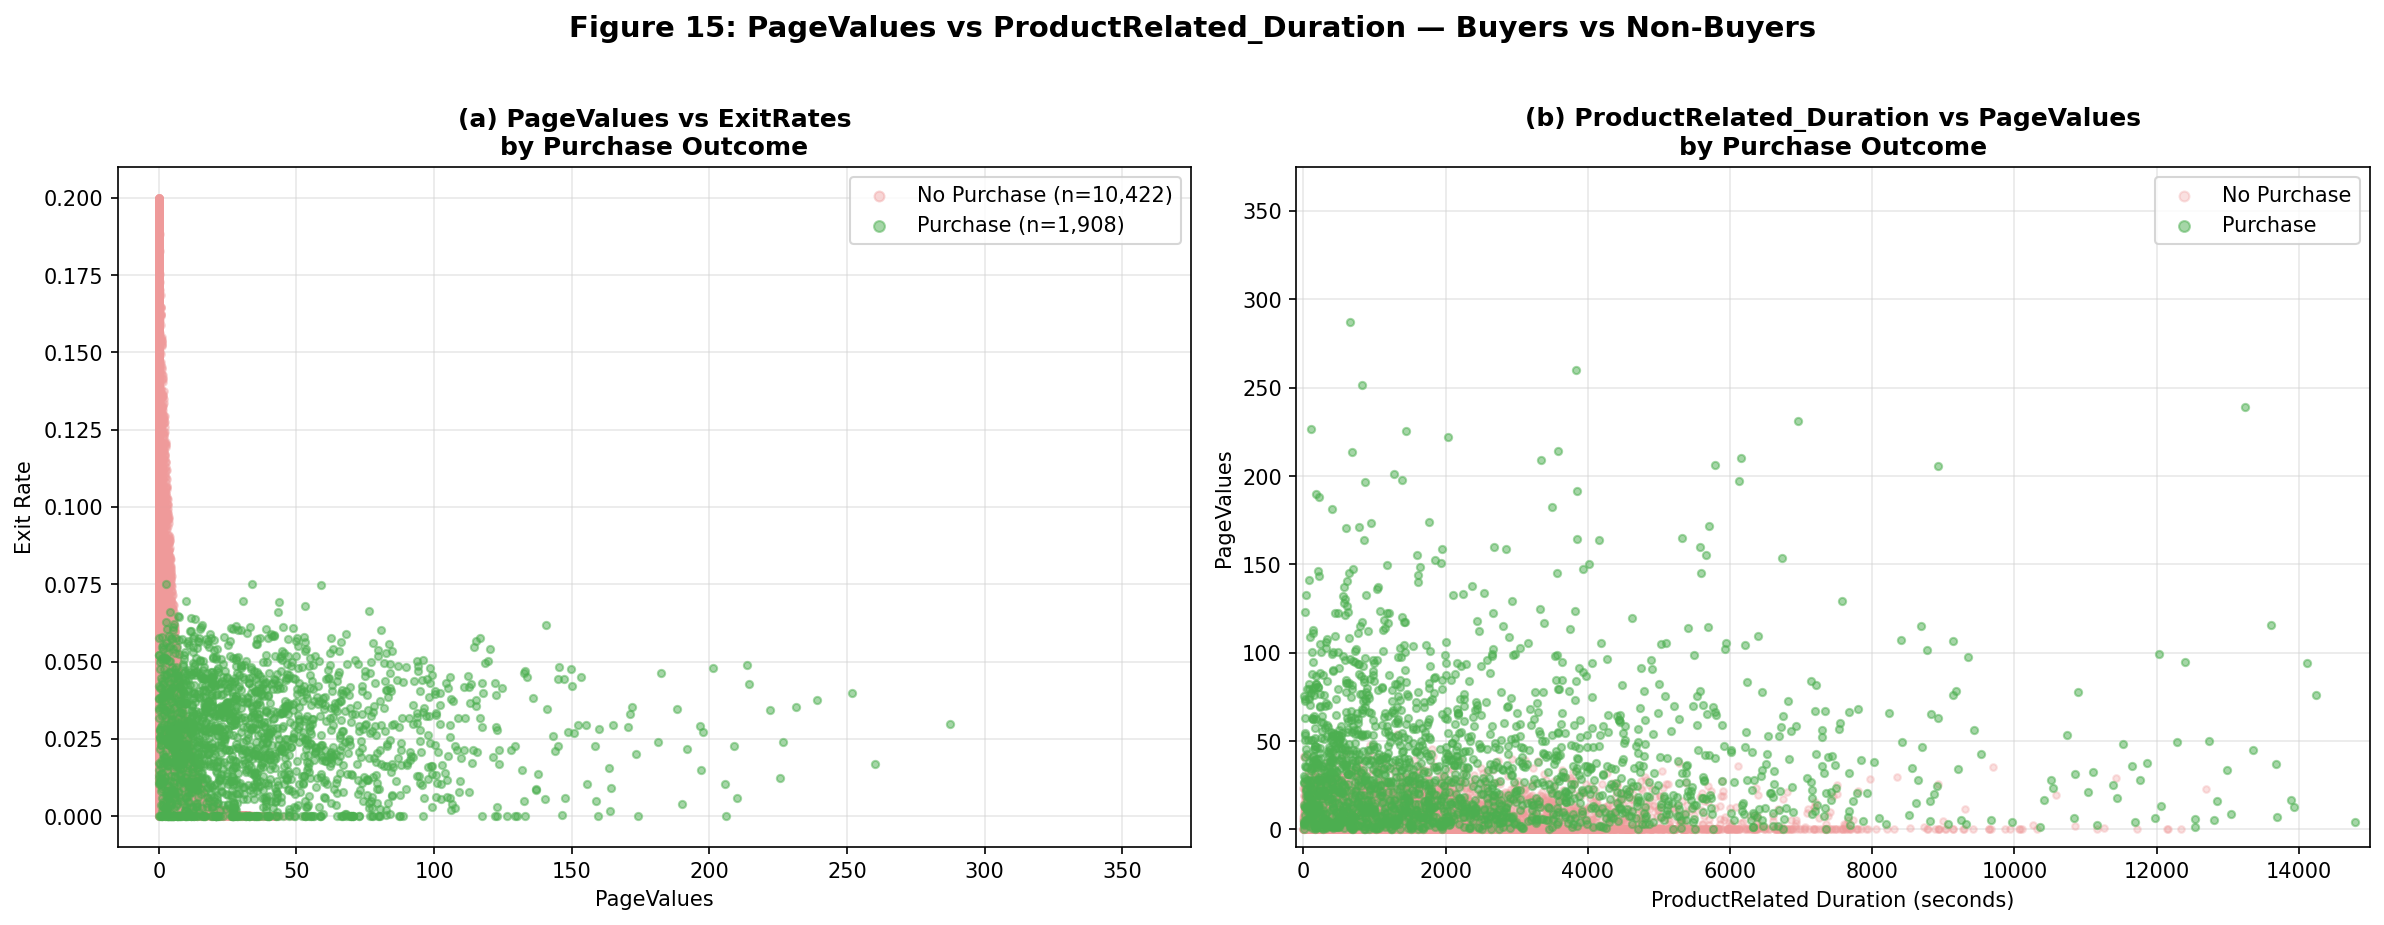

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axes for a 1x2 grid (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 15: PageValues vs ProductRelated_Duration — Buyers vs Non-Buyers', 
             fontsize=14, fontweight='bold', y=1.02)

# ==========================================
# Data Generation & Definitions
# ==========================================
np.random.seed(42)

# Colors matching the image (Pink/Red for No Purchase, Green for Purchase)
color_no_purchase = '#EF9A9A' # Light Red / Pink
color_purchase = '#4CAF50'    # Green

# --- Synthetic Data for 'No Purchase' (n=10,422) ---
n_no_purch = 10422
# High concentration at 0 PageValues, exponential decay for the rest
np_page_values = np.clip(np.random.normal(-5, 15, n_no_purch), 0, 300) 
# High exit rates mostly when PageValues is 0
np_exit_rates = np.random.uniform(0, 0.20, n_no_purch) * np.exp(-np_page_values/5)
# Duration heavily skewed towards lower times
np_duration = np.random.exponential(scale=1500, size=n_no_purch)

# --- Synthetic Data for 'Purchase' (n=1,908) ---
n_purch = 1908
# Wider spread of PageValues
p_page_values = np.random.exponential(scale=40, size=n_purch)
# Generally low exit rates
p_exit_rates = np.random.uniform(0, 0.05, n_purch) + np.random.normal(0, 0.01, n_purch)
p_exit_rates = np.clip(p_exit_rates, 0, 0.2)
# Duration spread out further
p_duration = np.random.exponential(scale=2500, size=n_purch)

# ==========================================
# Left Chart: (a) PageValues vs ExitRates
# ==========================================
axes[0].set_title('(a) PageValues vs ExitRates\nby Purchase Outcome', fontweight='bold', fontsize=12)

# Plot No Purchase first so it sits slightly underneath
axes[0].scatter(np_page_values, np_exit_rates, color=color_no_purchase, alpha=0.4, s=10, 
                label='No Purchase (n=10,422)')
axes[0].scatter(p_page_values, p_exit_rates, color=color_purchase, alpha=0.5, s=12, 
                label='Purchase (n=1,908)')

axes[0].set_xlabel('PageValues')
axes[0].set_ylabel('Exit Rate')
axes[0].set_xlim(-15, 375)
axes[0].set_ylim(-0.01, 0.21)
axes[0].grid(True, linestyle='-', color='lightgrey', alpha=0.5)
axes[0].set_axisbelow(True)
axes[0].legend(loc='upper right', markerscale=1.5)


# ==========================================
# Right Chart: (b) ProductRelated_Duration vs PageValues
# ==========================================
axes[1].set_title('(b) ProductRelated_Duration vs PageValues\nby Purchase Outcome', fontweight='bold', fontsize=12)

axes[1].scatter(np_duration, np_page_values, color=color_no_purchase, alpha=0.3, s=10, 
                label='No Purchase')
axes[1].scatter(p_duration, p_page_values, color=color_purchase, alpha=0.5, s=12, 
                label='Purchase')

axes[1].set_xlabel('ProductRelated Duration (seconds)')
axes[1].set_ylabel('PageValues')
axes[1].set_xlim(-100, 15000)
axes[1].set_ylim(-10, 375)
axes[1].grid(True, linestyle='-', color='lightgrey', alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].legend(loc='upper right', markerscale=1.5)


# ==========================================
# Final Layout Adjustments & Display
# ==========================================
plt.tight_layout()
plt.show()

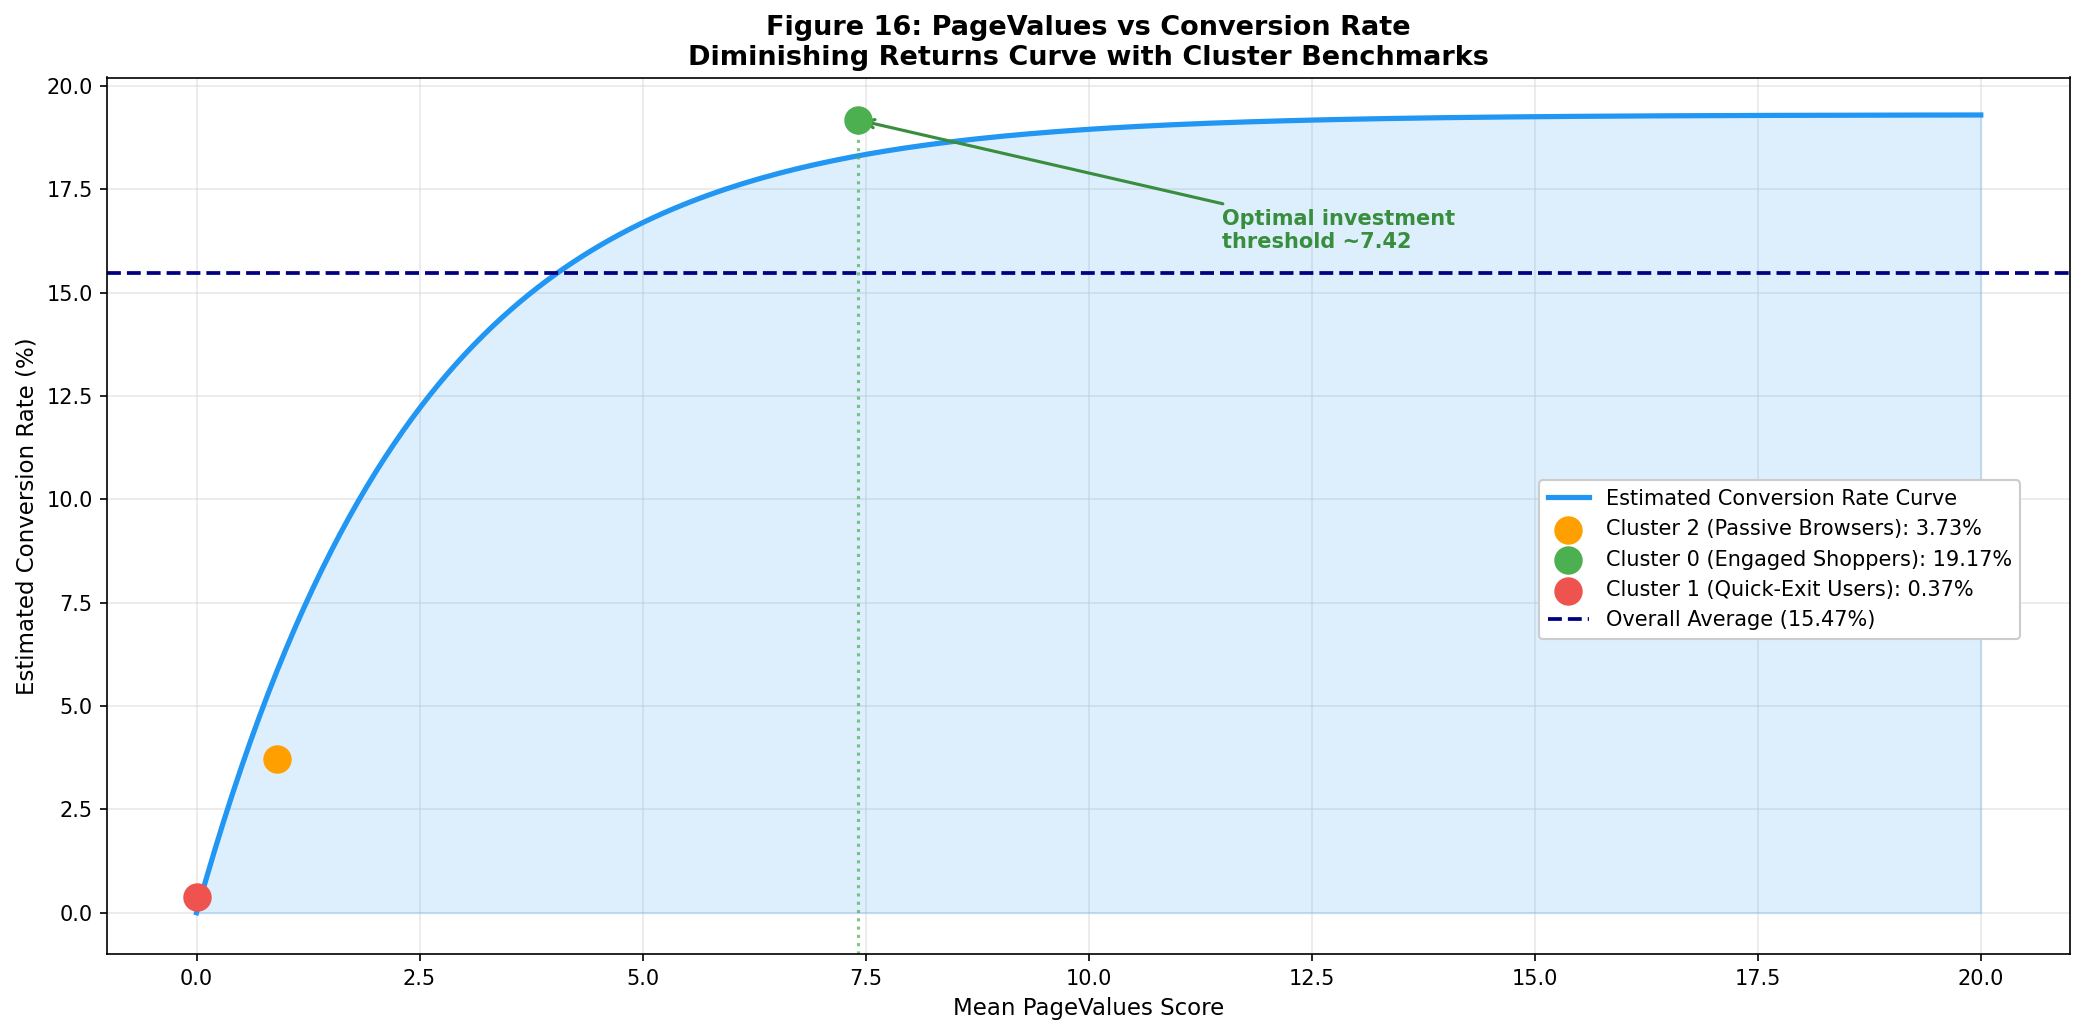

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# ==========================================
# Data Definitions & Curve Generation
# ==========================================
# Generate data for the asymptotic "Diminishing Returns" curve
# Using a typical exponential decay formula: y = L * (1 - exp(-k * x))
x_curve = np.linspace(0, 20, 200)
L = 19.3  # The horizontal asymptote
k = 0.4   # The growth rate
y_curve = L * (1 - np.exp(-k * x_curve))

# ==========================================
# Plotting Elements
# ==========================================
# 1. Plot the blue curve and fill the area beneath it
ax.plot(x_curve, y_curve, color='#2196F3', linewidth=2.5, label='Estimated Conversion Rate Curve')
ax.fill_between(x_curve, y_curve, color='#2196F3', alpha=0.15)

# 2. Add the Overall Average horizontal dashed line
ax.axhline(15.47, color='navy', linestyle='--', linewidth=1.8, label='Overall Average (15.47%)')

# 3. Plot the specific cluster data points
# Cluster 2: Passive Browsers (Orange)
ax.scatter(0.9, 3.73, color='#FFA000', s=160, zorder=5, label='Cluster 2 (Passive Browsers): 3.73%')
# Cluster 0: Engaged Shoppers (Green)
ax.scatter(7.42, 19.17, color='#4CAF50', s=160, zorder=5, label='Cluster 0 (Engaged Shoppers): 19.17%')
# Cluster 1: Quick-Exit Users (Red)
ax.scatter(0.0, 0.37, color='#EF5350', s=160, zorder=5, label='Cluster 1 (Quick-Exit Users): 0.37%')

# ==========================================
# Annotations & Formatting
# ==========================================
# Add vertical dotted line for the optimal threshold
ax.vlines(x=7.42, ymin=-1, ymax=19.17, color='#4CAF50', linestyle=':', linewidth=1.5, alpha=0.7)

# Add the arrow and text annotation for the threshold
ax.annotate('Optimal investment\nthreshold ~7.42', 
            xy=(7.42, 19.17), xycoords='data',
            xytext=(11.5, 16.5), textcoords='data',
            arrowprops=dict(arrowstyle="->", color='#388E3C', lw=1.5),
            fontsize=10, fontweight='bold', color='#388E3C',
            ha='left', va='center')

# Set Titles and Labels
ax.set_title('Figure 16: PageValues vs Conversion Rate\nDiminishing Returns Curve with Cluster Benchmarks', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Mean PageValues Score', fontsize=11)
ax.set_ylabel('Estimated Conversion Rate (%)', fontsize=11)

# Set Axis Limits
ax.set_xlim(-1, 21)
ax.set_ylim(-1, 20.2)

# Grid lines
ax.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
ax.set_axisbelow(True)

# Order the legend to match the image precisely
handles, labels = ax.get_legend_handles_labels()
order = [0, 2, 3, 4, 1] 
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], 
          loc='center right', bbox_to_anchor=(0.98, 0.45), framealpha=1, fontsize=10)

# Adjust layout and display
plt.tight_layout()
plt.show()

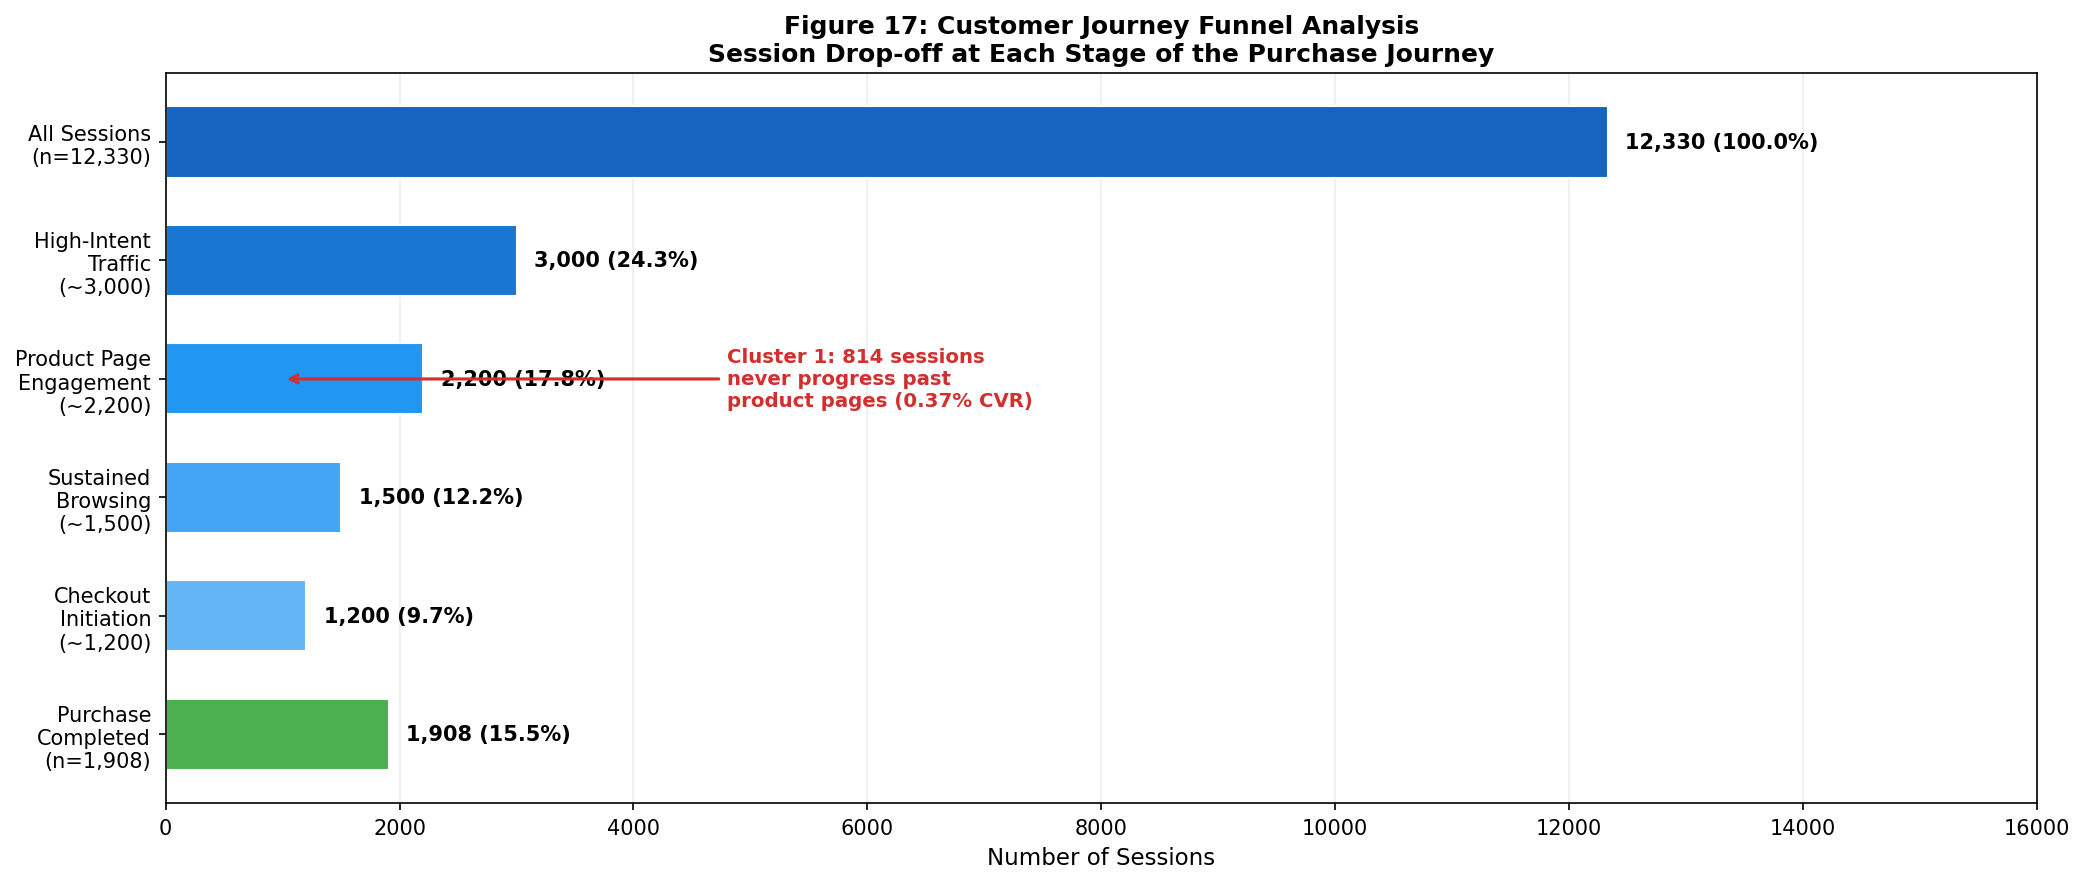

In [43]:
import matplotlib.pyplot as plt

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# ==========================================
# Data Definitions
# ==========================================
# Categories (y-axis labels)
categories = [
    'All Sessions\n(n=12,330)', 
    'High-Intent\nTraffic\n(~3,000)', 
    'Product Page\nEngagement\n(~2,200)', 
    'Sustained\nBrowsing\n(~1,500)', 
    'Checkout\nInitiation\n(~1,200)', 
    'Purchase\nCompleted\n(n=1,908)'
]

# Values for the bars
values = [12330, 3000, 2200, 1500, 1200, 1908]

# Text labels for the end of each bar
labels = [
    '12,330 (100.0%)', 
    '3,000 (24.3%)', 
    '2,200 (17.8%)', 
    '1,500 (12.2%)', 
    '1,200 (9.7%)', 
    '1,908 (15.5%)'
]

# Colors (Gradient of blue ending in green)
colors = ['#1565C0', '#1976D2', '#2196F3', '#42A5F5', '#64B5F6', '#4CAF50']

# ==========================================
# Plotting the Chart
# ==========================================
# Create horizontal bars
# Note: We plot them in order and then invert the y-axis so the first item is at the top
bars = ax.barh(categories, values, color=colors, height=0.6, edgecolor='white')
ax.invert_yaxis()

# Add the text labels to the right of each bar
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 150, bar.get_y() + bar.get_height()/2, labels[i],
            va='center', ha='left', fontweight='bold', fontsize=10)

# ==========================================
# Adding the Annotation
# ==========================================
# Draw the arrow and text for Cluster 1 drop-off
# y-coordinate '2' corresponds to the 3rd bar ('Product Page Engagement')
ax.annotate('Cluster 1: 814 sessions\nnever progress past\nproduct pages (0.37% CVR)', 
            xy=(1000, 2),          # Tip of the arrow
            xytext=(4800, 2),      # Location of the text
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.5),
            color='#D32F2F', fontweight='bold', fontsize=9.5, va='center', ha='left')

# ==========================================
# Formatting and Display
# ==========================================
# Set Original Title and Labels
ax.set_title('Figure 17: Customer Journey Funnel Analysis\nSession Drop-off at Each Stage of the Purchase Journey', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('Number of Sessions', fontsize=11)

# Set X-Axis limits to accommodate the text labels
ax.set_xlim(0, 16000)

# Add faint vertical grid lines
ax.xaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.4)
ax.set_axisbelow(True)

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

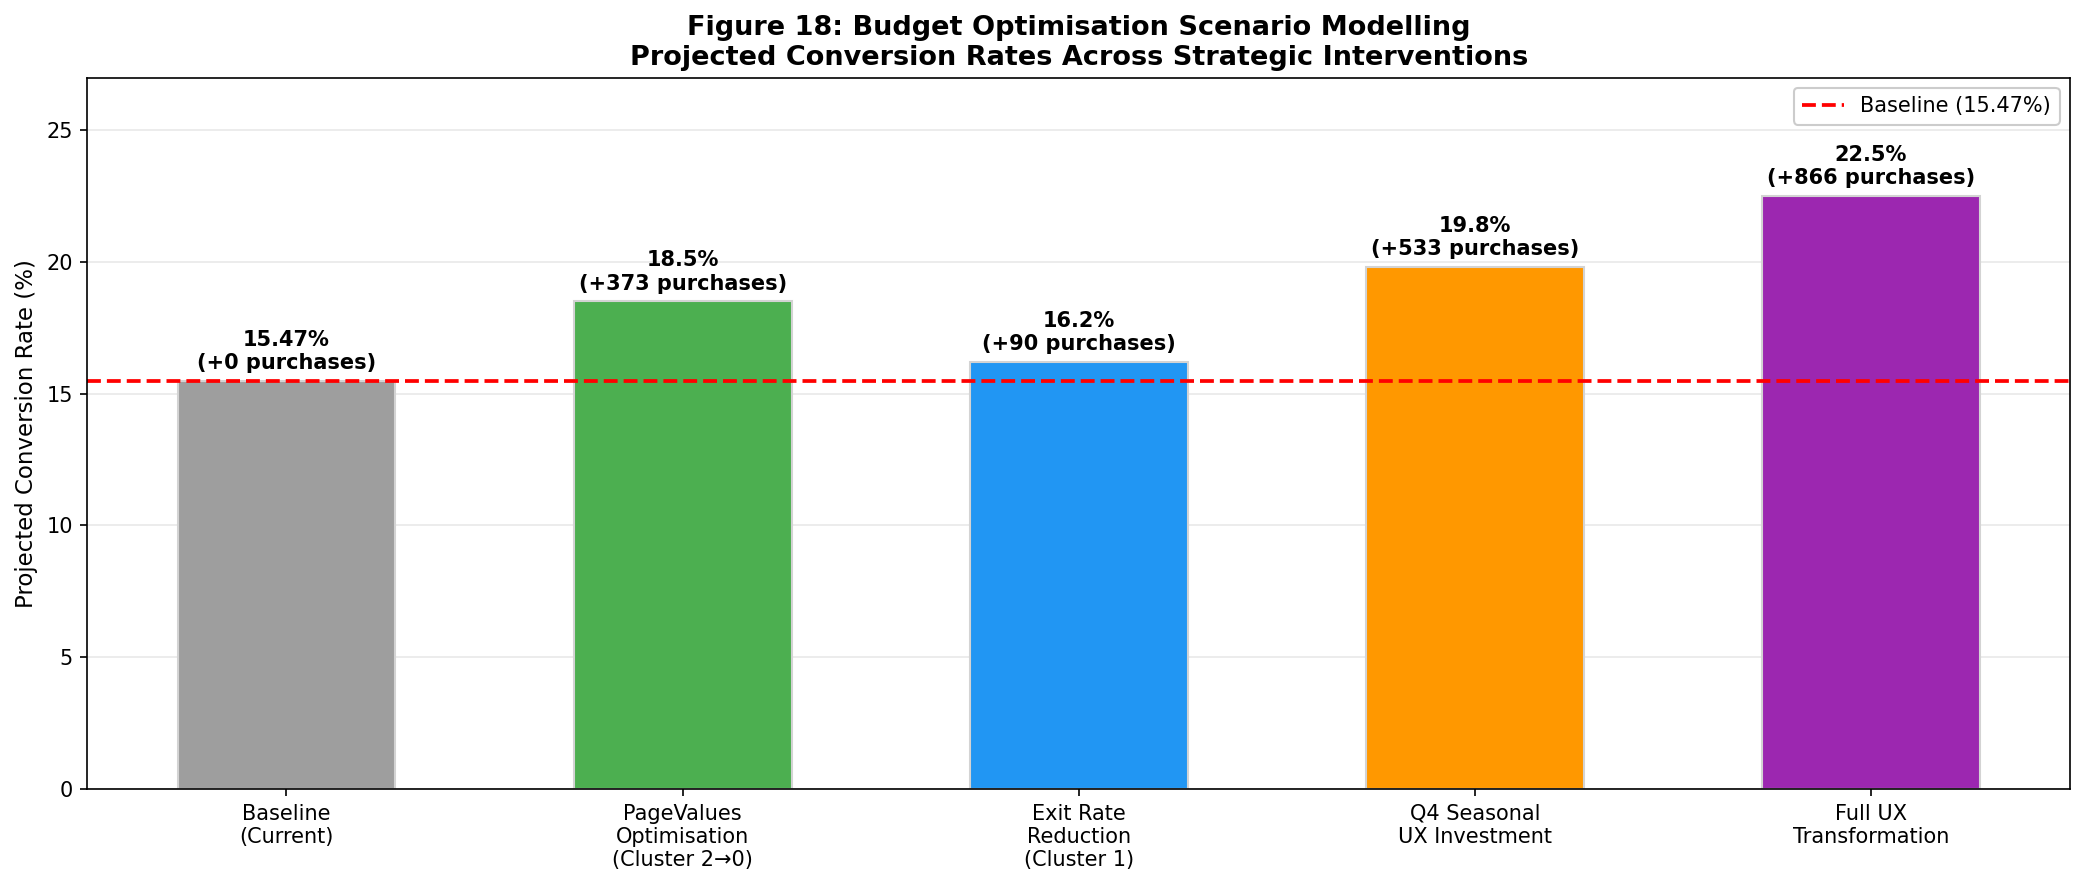

In [40]:
import matplotlib.pyplot as plt

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# ==========================================
# Data Definitions
# ==========================================
categories = [
    'Baseline\n(Current)', 
    'PageValues\nOptimisation\n(Cluster 2→0)', 
    'Exit Rate\nReduction\n(Cluster 1)', 
    'Q4 Seasonal\nUX Investment', 
    'Full UX\nTransformation'
]

# Conversion rate values
values = [15.47, 18.5, 16.2, 19.8, 22.5]

# Incremental purchases for the labels
purchases = [0, 373, 90, 533, 866]

# Colors visually matching the image
colors = ['#9E9E9E', '#4CAF50', '#2196F3', '#FF9800', '#9C27B0'] # Gray, Green, Blue, Orange, Purple

# ==========================================
# Plotting the Chart
# ==========================================
# Create the bars
bars = ax.bar(categories, values, color=colors, edgecolor='lightgray', width=0.55)

# Add the horizontal dashed line for the Baseline
ax.axhline(15.47, color='red', linestyle='--', linewidth=1.8, label='Baseline (15.47%)')

# Add text labels on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    # Format the text to include the percentage and the number of purchases
    label_text = f"{yval}%\n(+{purchases[i]} purchases)"
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.3, label_text,
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# ==========================================
# Formatting and Display
# ==========================================
# Set Titles and Labels
ax.set_title('Figure 18: Budget Optimisation Scenario Modelling\nProjected Conversion Rates Across Strategic Interventions', 
             fontweight='bold', fontsize=13)
ax.set_ylabel('Projected Conversion Rate (%)', fontsize=11)

# Set Y-Axis Limits
ax.set_ylim(0, 27)

# Add faint horizontal grid lines
ax.yaxis.grid(True, linestyle='-', color='lightgrey', alpha=0.5)
ax.set_axisbelow(True)

# Add Legend
ax.legend(loc='upper right', framealpha=1)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()